CSC4182: Natural Language Processing

Programming Assignment 01

# Comparison of Tokenization and Embedding Methods on an NER Pipeline

Mount google drive and import libraries

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:

import os
import numpy as np
import pandas as pd


Check the file format and load the data

In [3]:
# ============================================================
# CHECK DATASET FILE FORMAT
# ============================================================

DATA_DIR = "/content/drive/MyDrive/assignment"

train_path = DATA_DIR + "/train.txt"
val_path   = DATA_DIR + "/val.txt"
test_path  = DATA_DIR + "/test.txt"

# Print first 30 lines of train.txt
with open(train_path, "r", encoding="utf-8") as f:
    for i in range(30):
        print(repr(f.readline()))

'Selegiline\tO\n'
'-\tO\n'
'induced\tO\n'
'postural\tB-Disease\n'
'hypotension\tI-Disease\n'
'in\tO\n'
'Parkinson\tB-Disease\n'
"'\tI-Disease\n"
's\tI-Disease\n'
'disease\tI-Disease\n'
':\tO\n'
'a\tO\n'
'longitudinal\tO\n'
'study\tO\n'
'on\tO\n'
'the\tO\n'
'effects\tO\n'
'of\tO\n'
'drug\tO\n'
'withdrawal\tO\n'
'.\tO\n'
'\n'
'OBJECTIVES\tO\n'
':\tO\n'
'The\tO\n'
'United\tO\n'
'Kingdom\tO\n'
'Parkinson\tB-Disease\n'
"'\tI-Disease\n"
's\tI-Disease\n'


EDA

Train sentences: 4560
Validation sentences: 4581
Test sentences: 4797

Example sentence:
['Selegiline', '-', 'induced', 'postural', 'hypotension', 'in', 'Parkinson', "'", 's', 'disease', ':', 'a', 'longitudinal', 'study', 'on', 'the', 'effects', 'of', 'drug', 'withdrawal', '.']

Example labels:
['O', 'O', 'O', 'B-Disease', 'I-Disease', 'O', 'B-Disease', 'I-Disease', 'I-Disease', 'I-Disease', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O']
Number of training sentences: 4560
Number of validation sentences: 4581
Number of test sentences: 4797
Number of training tokens: 118170
Number of validation tokens: 117453
Number of test tokens: 124750

Minimum sentence length: 2
Maximum sentence length: 154
Average sentence length: 25.914473684210527
Median sentence length: 23.0


Unique tags:
['B-Disease', 'I-Disease', 'O']


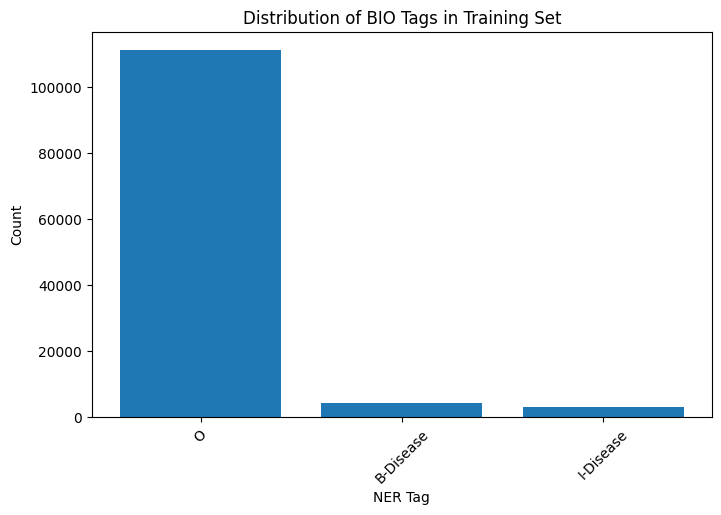


Vocabulary size: 8739
Total tokens: 118170

DISPLAY SAMPLE SENTENCE WITH TAGS


,Token,Tag
0,Selegiline,O
1,-,O
2,induced,O
3,postural,B-Disease
4,hypotension,I-Disease
5,in,O
6,Parkinson,B-Disease
7,',I-Disease
8,s,I-Disease
9,disease,I-Disease


In [4]:
# ============================================================
# LOAD CoNLL STYLE NER DATASET
# ============================================================

def read_ner_file(filepath):
    sentences = []
    labels = []

    sentence = []
    label_seq = []

    with open(filepath, "r", encoding="utf-8") as file:
        for line in file:
            line = line.strip()

            # Blank line means sentence ended
            if line == "":
                if len(sentence) > 0:
                    sentences.append(sentence)
                    labels.append(label_seq)
                    sentence = []
                    label_seq = []
            else:
                parts = line.split()

                # token is first column, tag is last column
                token = parts[0]
                tag = parts[-1]

                sentence.append(token)
                label_seq.append(tag)

    # Add last sentence if file does not end with blank line
    if len(sentence) > 0:
        sentences.append(sentence)
        labels.append(label_seq)

    return sentences, labels


train_sentences, train_labels = read_ner_file(train_path)
val_sentences, val_labels = read_ner_file(val_path)
test_sentences, test_labels = read_ner_file(test_path)

print("Train sentences:", len(train_sentences))
print("Validation sentences:", len(val_sentences))
print("Test sentences:", len(test_sentences))

print("\nExample sentence:")
print(train_sentences[0])

print("\nExample labels:")
print(train_labels[0])


# ============================================================
# BASIC DATASET SIZE
# ============================================================


print("Number of training sentences:", len(train_sentences))
print("Number of validation sentences:", len(val_sentences))
print("Number of test sentences:", len(test_sentences))

print("Number of training tokens:", sum(len(s) for s in train_sentences))
print("Number of validation tokens:", sum(len(s) for s in val_sentences))
print("Number of test tokens:", sum(len(s) for s in test_sentences))
print()
# ============================================================
# SENTENCE LENGTH STATISTICS
# ============================================================

train_lengths = [len(sentence) for sentence in train_sentences]

print("Minimum sentence length:", min(train_lengths))
print("Maximum sentence length:", max(train_lengths))
print("Average sentence length:", np.mean(train_lengths))
print("Median sentence length:", np.median(train_lengths))
print()

# ============================================================
# TAG DISTRIBUTION
# ============================================================

from collections import Counter

all_train_tags = [tag for label_seq in train_labels for tag in label_seq]

tag_counts = Counter(all_train_tags)

tag_df = pd.DataFrame(tag_counts.items(), columns=["Tag", "Count"])
tag_df = tag_df.sort_values(by="Count", ascending=False)

tag_df
print()
# ============================================================
# CHECK UNIQUE TAGS
# ============================================================

unique_tags = sorted(set(tag for label_seq in train_labels for tag in label_seq))

print("Unique tags:")
print(unique_tags)

# ============================================================
# PLOT TAG DISTRIBUTION
# ============================================================

import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.bar(tag_df["Tag"], tag_df["Count"])
plt.xlabel("NER Tag")
plt.ylabel("Count")
plt.title("Distribution of BIO Tags in Training Set")
plt.xticks(rotation=45)
plt.show()


# ============================================================
# VOCABULARY SIZE
# ============================================================

all_train_words = [word.lower() for sentence in train_sentences for word in sentence]

vocab = set(all_train_words)

print()
print("Vocabulary size:", len(vocab))
print("Total tokens:", len(all_train_words))
print()

# ============================================================
# DISPLAY SAMPLE SENTENCE WITH TAGS
# ============================================================
print("DISPLAY SAMPLE SENTENCE WITH TAGS")
sample_id = 0

sample_df = pd.DataFrame({
    "Token": train_sentences[sample_id],
    "Tag": train_labels[sample_id]
})

sample_df

In [5]:
# ============================================================
# LOAD CoNLL STYLE NER DATASET
# ============================================================

def read_ner_file(filepath):
    sentences = []
    labels = []

    sentence = []
    label_seq = []

    with open(filepath, "r", encoding="utf-8") as file:
        for line in file:
            line = line.strip()

            # Blank line means sentence ended
            if line == "":
                if len(sentence) > 0:
                    sentences.append(sentence)
                    labels.append(label_seq)
                    sentence = []
                    label_seq = []
            else:
                parts = line.split()

                # token is first column, tag is last column
                token = parts[0]
                tag = parts[-1]

                sentence.append(token)
                label_seq.append(tag)

    # Add last sentence if file does not end with blank line
    if len(sentence) > 0:
        sentences.append(sentence)
        labels.append(label_seq)

    return sentences, labels


train_sentences, train_labels = read_ner_file(train_path)
val_sentences, val_labels = read_ner_file(val_path)
test_sentences, test_labels = read_ner_file(test_path)

print("Train sentences:", len(train_sentences))
print("Validation sentences:", len(val_sentences))
print("Test sentences:", len(test_sentences))

print("\nExample sentence:")
print(train_sentences[0])

print("\nExample labels:")
print(train_labels[0])

Train sentences: 4560
Validation sentences: 4581
Test sentences: 4797

Example sentence:
['Selegiline', '-', 'induced', 'postural', 'hypotension', 'in', 'Parkinson', "'", 's', 'disease', ':', 'a', 'longitudinal', 'study', 'on', 'the', 'effects', 'of', 'drug', 'withdrawal', '.']

Example labels:
['O', 'O', 'O', 'B-Disease', 'I-Disease', 'O', 'B-Disease', 'I-Disease', 'I-Disease', 'I-Disease', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O']


## Exploratory Data Analysis

A basic exploratory data analysis was performed to understand the BC5CDR dataset before model training. The number of sentences and tokens in the training, validation, and test sets were examined. Sentence length statistics were calculated to choose a suitable maximum sequence length for padding. The distribution of BIO tags was also analyzed to identify class imbalance between disease entity tags and the outside class.

Prepare mappings for modeling

In [6]:
# ============================================================
# CREATE WORD AND TAG MAPPINGS
# ============================================================

MAX_LEN = 50 # Corrected MAX_LEN to 50 to match ELMo model's expected input length

# Create vocabulary from training data only
all_words = sorted(set(word.lower() for sentence in train_sentences for word in sentence))

word2idx = {word: idx + 2 for idx, word in enumerate(all_words)}
word2idx["PAD"] = 0
word2idx["UNK"] = 1

idx2word = {idx: word for word, idx in word2idx.items()}

# Create tag mappings
tag2idx = {
    "O": 0,
    "B-Disease": 1,
    "I-Disease": 2
}

idx2tag = {idx: tag for tag, idx in tag2idx.items()}

print("Vocabulary size:", len(word2idx))
print("Number of tags:", len(tag2idx))
print("word2idx sample:", list(word2idx.items())[:10])
print("tag2idx:", tag2idx)

Vocabulary size: 8741
Number of tags: 3
word2idx sample: [('"', 2), ('%', 3), ("'", 4), ('(', 5), (')', 6), ('+', 7), (',', 8), ('-', 9), ('.', 10), ('/', 11)]
tag2idx: {'O': 0, 'B-Disease': 1, 'I-Disease': 2}


Convert sentences and labels into numbers

In [7]:
# ============================================================
# CONVERT TEXT AND LABELS TO NUMERICAL SEQUENCES
# ============================================================

from tensorflow.keras.preprocessing.sequence import pad_sequences

def encode_sentences(sentences, word2idx, max_len):
    encoded = []

    for sentence in sentences:
        encoded_sentence = [
            word2idx.get(word.lower(), word2idx["UNK"])
            for word in sentence
        ]
        encoded.append(encoded_sentence)

    padded = pad_sequences(
        encoded,
        maxlen=max_len,
        padding="post",
        truncating="post",
        value=word2idx["PAD"]
    )

    return padded


def encode_labels(labels, tag2idx, max_len):
    encoded = []

    for label_seq in labels:
        encoded_label = [tag2idx[tag] for tag in label_seq]
        encoded.append(encoded_label)

    padded = pad_sequences(
        encoded,
        maxlen=max_len,
        padding="post",
        truncating="post",
        value=tag2idx["O"]
    )

    return padded


X_train = encode_sentences(train_sentences, word2idx, MAX_LEN)
X_val = encode_sentences(val_sentences, word2idx, MAX_LEN)
X_test = encode_sentences(test_sentences, word2idx, MAX_LEN)

y_train = encode_labels(train_labels, tag2idx, MAX_LEN)
y_val = encode_labels(val_labels, tag2idx, MAX_LEN)
y_test = encode_labels(test_labels, tag2idx, MAX_LEN)

print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)

print("X_val shape:", X_val.shape)
print("y_val shape:", y_val.shape)

print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)

X_train shape: (4560, 50)
y_train shape: (4560, 50)
X_val shape: (4581, 50)
y_val shape: (4581, 50)
X_test shape: (4797, 50)
y_test shape: (4797, 50)


Build Baseline BiLSTM + Softmax Model

In [8]:
# ============================================================
# BUILD BASELINE BiLSTM + SOFTMAX MODEL
# ============================================================

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Embedding, Bidirectional, LSTM, Dense, TimeDistributed

num_words = len(word2idx)
num_tags = len(tag2idx)

baseline_model = Sequential([
    Input(shape=(MAX_LEN,)),

    Embedding(
        input_dim=num_words,
        output_dim=100,
        mask_zero=True
    ),

    Bidirectional(LSTM(
        units=64,
        return_sequences=True,
        dropout=0.3,
        recurrent_dropout=0.3
    )),

    TimeDistributed(Dense(
        num_tags,
        activation="softmax"
    ))
])

baseline_model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

baseline_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 50, 100)        │       874,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 50, 128)        │        84,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed                │ (None, 50, 3)          │           387 │
│ (TimeDistributed)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 958,967 (3.66 MB)

 Trainable params: 958,967 (3.66 MB)

 Non-trainable params: 0 (0.00 B)

In [9]:
# ============================================================
# TRAIN BASELINE MODEL
# ============================================================

y_train_expanded = y_train[..., np.newaxis]
y_val_expanded = y_val[..., np.newaxis]

history_baseline = baseline_model.fit(
    X_train,
    y_train_expanded,
    validation_data=(X_val, y_val_expanded),
    batch_size=32,
    epochs=5
)

Epoch 1/5
143/143 ━━━━━━━━━━━━━━━━━━━━ 99s 567ms/step - accuracy: 0.9345 - loss: 0.2963 - val_accuracy: 0.9415 - val_loss: 0.1652
Epoch 2/5
143/143 ━━━━━━━━━━━━━━━━━━━━ 72s 506ms/step - accuracy: 0.9607 - loss: 0.1107 - val_accuracy: 0.9650 - val_loss: 0.1156
Epoch 3/5
143/143 ━━━━━━━━━━━━━━━━━━━━ 74s 521ms/step - accuracy: 0.9777 - loss: 0.0677 - val_accuracy: 0.9688 - val_loss: 0.1067
Epoch 4/5
143/143 ━━━━━━━━━━━━━━━━━━━━ 81s 512ms/step - accuracy: 0.9840 - loss: 0.0505 - val_accuracy: 0.9678 - val_loss: 0.1111
Epoch 5/5
143/143 ━━━━━━━━━━━━━━━━━━━━ 73s 509ms/step - accuracy: 0.9861 - loss: 0.0411 - val_accuracy: 0.9682 - val_loss: 0.1139


Plot and Evaluavte Baseline Model

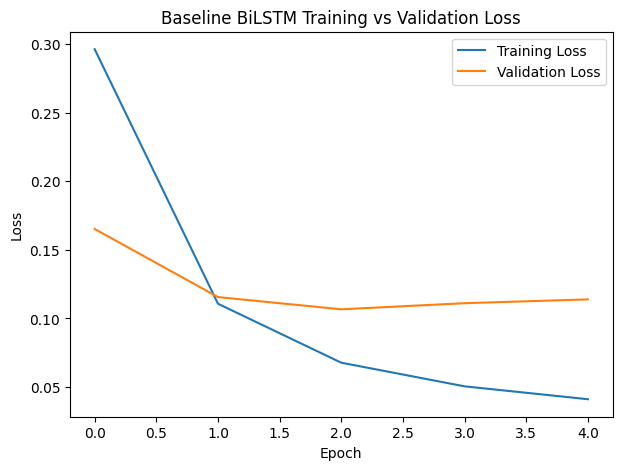

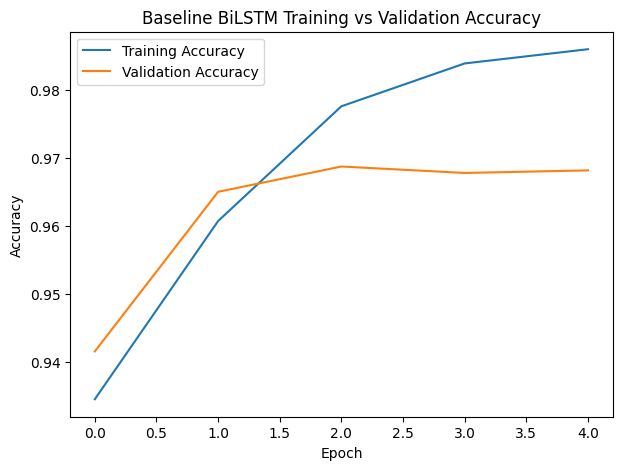

In [10]:
# ============================================================
# PLOT TRAINING AND VALIDATION CURVES
# ============================================================

import matplotlib.pyplot as plt

plt.figure(figsize=(7, 5))
plt.plot(history_baseline.history["loss"], label="Training Loss")
plt.plot(history_baseline.history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Baseline BiLSTM Training vs Validation Loss")
plt.legend()
plt.show()

plt.figure(figsize=(7, 5))
plt.plot(history_baseline.history["accuracy"], label="Training Accuracy")
plt.plot(history_baseline.history["val_accuracy"], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Baseline BiLSTM Training vs Validation Accuracy")
plt.legend()
plt.show()

In [11]:
# ============================================================
# EVALUATE BASELINE MODEL USING F1-SCORE
# ============================================================

from sklearn.metrics import classification_report, f1_score

def evaluate_model(model, X, y_true, idx2tag, pad_value=0):
    predictions = model.predict(X)
    y_pred = np.argmax(predictions, axis=-1)

    true_tags = []
    pred_tags = []

    for i in range(y_true.shape[0]):
        for j in range(y_true.shape[1]):

            # Ignore PAD positions using X value
            if X[i][j] != word2idx["PAD"]:
                true_tags.append(idx2tag[y_true[i][j]])
                pred_tags.append(idx2tag[y_pred[i][j]])

    print(classification_report(true_tags, pred_tags, digits=4))

    macro_f1 = f1_score(true_tags, pred_tags, average="macro")
    weighted_f1 = f1_score(true_tags, pred_tags, average="weighted")

    return macro_f1, weighted_f1


baseline_macro_f1, baseline_weighted_f1 = evaluate_model(
    baseline_model,
    X_test,
    y_test,
    idx2tag
)

print("Baseline Macro F1:", baseline_macro_f1)
print("Baseline Weighted F1:", baseline_weighted_f1)

150/150 ━━━━━━━━━━━━━━━━━━━━ 15s 90ms/step
              precision    recall  f1-score   support

   B-Disease     0.7452    0.6804    0.7113      4346
   I-Disease     0.6282    0.6759    0.6512      2697
           O     0.9847    0.9862    0.9855    112494

    accuracy                         0.9681    119537
   macro avg     0.7860    0.7809    0.7827    119537
weighted avg     0.9680    0.9681    0.9680    119537

Baseline Macro F1: 0.7826664994200302
Baseline Weighted F1: 0.9679718458207317


Save baseline result

In [12]:
# ============================================================
# STORE BASELINE RESULT
# ============================================================

results = []

results.append({
    "Embedding": "Trainable Embedding",
    "Tokenizer": "Original Dataset Tokenization",
    "Model": "BiLSTM + Softmax",
    "Macro F1": baseline_macro_f1,
    "Weighted F1": baseline_weighted_f1
})

results_df = pd.DataFrame(results)
results_df

,Embedding,Tokenizer,Model,Macro F1,Weighted F1
0,Trainable Embedding,Original Dataset Tokenization,BiLSTM + Softmax,0.782666,0.967972


### Baseline Model

A baseline BiLSTM model with a trainable embedding layer was implemented first. This model learns word embeddings directly from the BC5CDR training data. The purpose of this baseline is to provide a reference point before comparing pretrained/static/contextual embedding methods such as Word2Vec, GloVe, FastText, ELMo, and BERT.

move to the first required embedding method

In [13]:
# ============================================================
# INSTALL GENSIM
# ============================================================

!pip install gensim

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 72.6 MB/s eta 0:00:00


In [14]:
# ============================================================
# IMPORT WORD2VEC
# ============================================================

from gensim.models import Word2Vec

print("Word2Vec imported successfully!")

Word2Vec imported successfully!


In [15]:
# ============================================================
#  PREPARE SENTENCES FOR WORD2VEC
# ============================================================

train_sentences_lower = [
    [word.lower() for word in sentence]
    for sentence in train_sentences
]

print(train_sentences_lower[0])

['selegiline', '-', 'induced', 'postural', 'hypotension', 'in', 'parkinson', "'", 's', 'disease', ':', 'a', 'longitudinal', 'study', 'on', 'the', 'effects', 'of', 'drug', 'withdrawal', '.']


Train Word2Vec Model

In [16]:
# ============================================================
# TRAIN WORD2VEC EMBEDDINGS
# ============================================================

EMBEDDING_DIM = 100

word2vec_model = Word2Vec(
    sentences=train_sentences_lower,
    vector_size=EMBEDDING_DIM,
    window=5,
    min_count=1,
    workers=4,
    sg=1
)

print("Word2Vec vocabulary size:", len(word2vec_model.wv))
print("Vector size:", word2vec_model.vector_size)

Word2Vec vocabulary size: 8739
Vector size: 100


 CREATE WORD2VEC EMBEDDING MATRIX


In [17]:
# ============================================================
# CREATE WORD2VEC EMBEDDING MATRIX
# ============================================================

embedding_matrix_w2v = np.zeros((len(word2idx), EMBEDDING_DIM))

found_words = 0

for word, idx in word2idx.items():
    if word in word2vec_model.wv:
        embedding_matrix_w2v[idx] = word2vec_model.wv[word]
        found_words += 1

print("Words found in Word2Vec:", found_words)
print("Total vocabulary size:", len(word2idx))
print("Coverage:", found_words / len(word2idx))
print("Embedding matrix shape:", embedding_matrix_w2v.shape)

Words found in Word2Vec: 8739
Total vocabulary size: 8741
Coverage: 0.9997711932273196
Embedding matrix shape: (8741, 100)


Build Word2Vec + BiLSTM model

In [18]:
# ============================================================
# BUILD WORD2VEC + BiLSTM MODEL
# ============================================================

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Embedding, Bidirectional, LSTM, Dense, TimeDistributed

word2vec_model_bilstm = Sequential([
    Input(shape=(MAX_LEN,)),

    Embedding(
        input_dim=len(word2idx),
        output_dim=EMBEDDING_DIM,
        weights=[embedding_matrix_w2v],
        mask_zero=True,
        trainable=False
    ),

    Bidirectional(LSTM(
        units=64,
        return_sequences=True,
        dropout=0.3,
        recurrent_dropout=0.3
    )),

    TimeDistributed(Dense(
        len(tag2idx),
        activation="softmax"
    ))
])

word2vec_model_bilstm.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

word2vec_model_bilstm.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ (None, 50, 100)        │       874,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ (None, 50, 128)        │        84,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_1              │ (None, 50, 3)          │           387 │
│ (TimeDistributed)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 958,967 (3.66 MB)

 Trainable params: 84,867 (331.51 KB)

 Non-trainable params: 874,100 (3.33 MB)

Train

In [19]:
# ============================================================
#  TRAIN WORD2VEC + BiLSTM MODEL
# ============================================================

history_w2v = word2vec_model_bilstm.fit(
    X_train,
    y_train_expanded,
    validation_data=(X_val, y_val_expanded),
    batch_size=32,
    epochs=5
)

Epoch 1/5
143/143 ━━━━━━━━━━━━━━━━━━━━ 110s 616ms/step - accuracy: 0.9360 - loss: 0.2838 - val_accuracy: 0.9392 - val_loss: 0.2400
Epoch 2/5
143/143 ━━━━━━━━━━━━━━━━━━━━ 78s 550ms/step - accuracy: 0.9389 - loss: 0.2317 - val_accuracy: 0.9404 - val_loss: 0.2204
Epoch 3/5
143/143 ━━━━━━━━━━━━━━━━━━━━ 73s 487ms/step - accuracy: 0.9400 - loss: 0.2155 - val_accuracy: 0.9417 - val_loss: 0.2044
Epoch 4/5
143/143 ━━━━━━━━━━━━━━━━━━━━ 71s 493ms/step - accuracy: 0.9412 - loss: 0.2042 - val_accuracy: 0.9423 - val_loss: 0.1901
Epoch 5/5
143/143 ━━━━━━━━━━━━━━━━━━━━ 81s 491ms/step - accuracy: 0.9427 - loss: 0.1954 - val_accuracy: 0.9457 - val_loss: 0.1823


Evaluate

In [20]:
# ============================================================
# EVALUATE WORD2VEC MODEL
# ============================================================

w2v_macro_f1, w2v_weighted_f1 = evaluate_model(
    word2vec_model_bilstm,
    X_test,
    y_test,
    idx2tag
)

print("Word2Vec Macro F1:", w2v_macro_f1)
print("Word2Vec Weighted F1:", w2v_weighted_f1)

150/150 ━━━━━━━━━━━━━━━━━━━━ 15s 94ms/step
              precision    recall  f1-score   support

   B-Disease     0.6585    0.1367    0.2264      4346
   I-Disease     0.7139    0.1832    0.2915      2697
           O     0.9507    0.9968    0.9732    112494

    accuracy                         0.9472    119537
   macro avg     0.7744    0.4389    0.4970    119537
weighted avg     0.9348    0.9472    0.9307    119537

Word2Vec Macro F1: 0.4970441673165807
Word2Vec Weighted F1: 0.9306951822553085


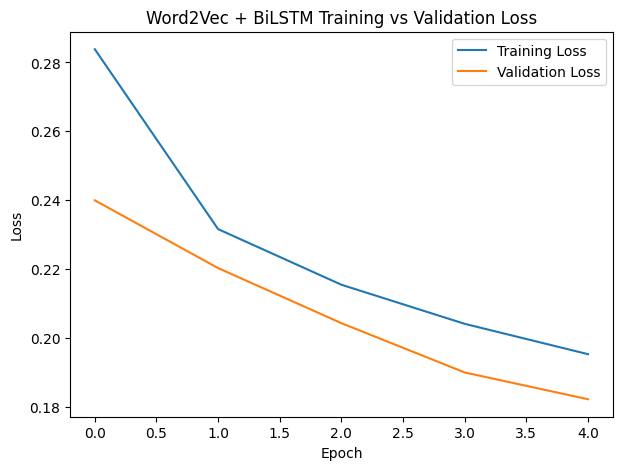

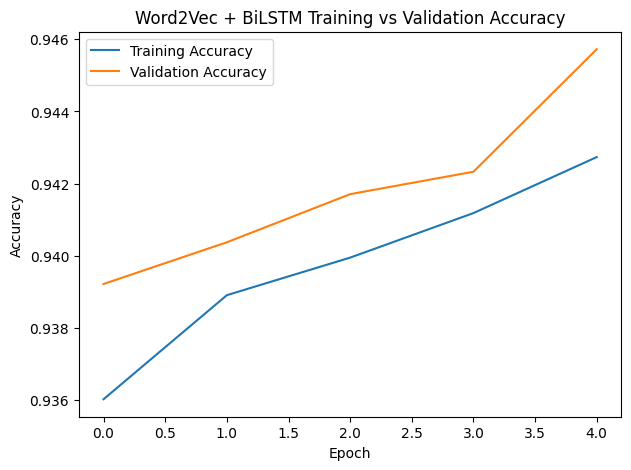

In [21]:
# ============================================================
# PLOT WORD2VEC TRAINING CURVES
# ============================================================

import matplotlib.pyplot as plt

plt.figure(figsize=(7, 5))
plt.plot(history_w2v.history["loss"], label="Training Loss")
plt.plot(history_w2v.history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Word2Vec + BiLSTM Training vs Validation Loss")
plt.legend()
plt.show()

plt.figure(figsize=(7, 5))
plt.plot(history_w2v.history["accuracy"], label="Training Accuracy")
plt.plot(history_w2v.history["val_accuracy"], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Word2Vec + BiLSTM Training vs Validation Accuracy")
plt.legend()
plt.show()

In [22]:
# ============================================================
# SAVE WORD2VEC RESULT
# ============================================================

results.append({
    "Embedding": "Word2Vec",
    "Tokenizer": "Original Dataset Tokenization",
    "Model": "BiLSTM + Softmax",
    "Macro F1": w2v_macro_f1,
    "Weighted F1": w2v_weighted_f1
})

results_df = pd.DataFrame(results)
results_df

,Embedding,Tokenizer,Model,Macro F1,Weighted F1
0,Trainable Embedding,Original Dataset Tokenization,BiLSTM + Softmax,0.782666,0.967972
1,Word2Vec,Original Dataset Tokenization,BiLSTM + Softmax,0.497044,0.930695


In [ ]:
# ============================================================
# CREATE WORDPIECE AND NLTK TOKENIZED DATASETS
# ============================================================

!pip install nltk transformers

import nltk
nltk.download("punkt")
nltk.download("punkt_tab")

from nltk.tokenize import word_tokenize
from transformers import AutoTokenizer

wordpiece_tokenizer = AutoTokenizer.from_pretrained("bert-base-cased")


# -------------------------------
# WordPiece tokenization
# -------------------------------

def wordpiece_tokenize_with_labels(sentences, labels):
    new_sentences = []
    new_labels = []

    for sent, label_seq in zip(sentences, labels):
        wp_sent = []
        wp_labels = []

        for word, tag in zip(sent, label_seq):
            pieces = wordpiece_tokenizer.tokenize(word)

            if len(pieces) == 0:
                continue

            for i, piece in enumerate(pieces):
                wp_sent.append(piece)

                if i == 0:
                    wp_labels.append(tag)
                else:
                    if tag == "B-Disease":
                        wp_labels.append("I-Disease")
                    else:
                        wp_labels.append(tag)

        new_sentences.append(wp_sent)
        new_labels.append(wp_labels)

    return new_sentences, new_labels


# -------------------------------
# NLTK tokenization
# -------------------------------

def nltk_tokenize_with_labels(sentences, labels):
    new_sentences = []
    new_labels = []

    for sent, label_seq in zip(sentences, labels):
        nltk_sent = []
        nltk_labels = []

        for word, tag in zip(sent, label_seq):
            pieces = word_tokenize(word)

            if len(pieces) == 0:
                continue

            for i, piece in enumerate(pieces):
                nltk_sent.append(piece)

                if i == 0:
                    nltk_labels.append(tag)
                else:
                    if tag == "B-Disease":
                        nltk_labels.append("I-Disease")
                    else:
                        nltk_labels.append(tag)

        new_sentences.append(nltk_sent)
        new_labels.append(nltk_labels)

    return new_sentences, new_labels


# -------------------------------
# Create tokenized datasets
# -------------------------------

train_sentences_wp, train_labels_wp = wordpiece_tokenize_with_labels(train_sentences, train_labels)
val_sentences_wp, val_labels_wp = wordpiece_tokenize_with_labels(val_sentences, val_labels)
test_sentences_wp, test_labels_wp = wordpiece_tokenize_with_labels(test_sentences, test_labels)

train_sentences_nltk, train_labels_nltk = nltk_tokenize_with_labels(train_sentences, train_labels)
val_sentences_nltk, val_labels_nltk = nltk_tokenize_with_labels(val_sentences, val_labels)
test_sentences_nltk, test_labels_nltk = nltk_tokenize_with_labels(test_sentences, test_labels)

print("WordPiece train size:", len(train_sentences_wp))
print("NLTK train size:", len(train_sentences_nltk))

print("WordPiece example:", train_sentences_wp[0])
print("WordPiece labels:", train_labels_wp[0])

print("NLTK example:", train_sentences_nltk[0])
print("NLTK labels:", train_labels_nltk[0])

# Word2Vec Embedding Experiment

Word2Vec embeddings were trained using the training sentences of the BC5CDR dataset. The Skip-gram architecture was used with a vector size of 100 and window size of 5. The trained Word2Vec vectors were used to initialize the embedding layer of a BiLSTM model. The embedding layer was kept non-trainable to evaluate the effect of fixed Word2Vec embeddings on disease entity recognition.

FastText + BiLSTM + Softmax

In [23]:
# ============================================================
# IMPORT FASTTEXT
# ============================================================

from gensim.models import FastText

print("FastText imported successfully!")

FastText imported successfully!


Train FastText embeddings

In [24]:
# train_sentences_lower was already created earlier:
# train_sentences_lower = [[word.lower() for word in sentence] for sentence in train_sentences]

EMBEDDING_DIM = 100

fasttext_model = FastText(
    sentences=train_sentences_lower,
    vector_size=EMBEDDING_DIM,
    window=5,
    min_count=1,
    workers=4,
    sg=1
)

print("FastText vocabulary size:", len(fasttext_model.wv))
print("Vector size:", fasttext_model.vector_size)

FastText vocabulary size: 8739
Vector size: 100


In [25]:
# ============================================================
# CREATE FASTTEXT EMBEDDING MATRIX
# ============================================================

embedding_matrix_fasttext = np.zeros((len(word2idx), EMBEDDING_DIM))

found_words = 0

for word, idx in word2idx.items():
    if word in fasttext_model.wv:
        embedding_matrix_fasttext[idx] = fasttext_model.wv[word]
        found_words += 1

print("Words found in FastText:", found_words)
print("Total vocabulary size:", len(word2idx))
print("Coverage:", found_words / len(word2idx))
print("Embedding matrix shape:", embedding_matrix_fasttext.shape)

Words found in FastText: 8741
Total vocabulary size: 8741
Coverage: 1.0
Embedding matrix shape: (8741, 100)


In [26]:
# ============================================================
# BUILD FASTTEXT + BiLSTM MODEL
# ============================================================

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Embedding, Bidirectional, LSTM, Dense, TimeDistributed

fasttext_model_bilstm = Sequential([
    Input(shape=(MAX_LEN,)),

    Embedding(
        input_dim=len(word2idx),
        output_dim=EMBEDDING_DIM,
        weights=[embedding_matrix_fasttext],
        mask_zero=True,
        trainable=False
    ),

    Bidirectional(LSTM(
        units=64,
        return_sequences=True,
        dropout=0.3,
        recurrent_dropout=0.3
    )),

    TimeDistributed(Dense(
        len(tag2idx),
        activation="softmax"
    ))
])

fasttext_model_bilstm.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

fasttext_model_bilstm.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ (None, 50, 100)        │       874,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_2 (Bidirectional) │ (None, 50, 128)        │        84,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_2              │ (None, 50, 3)          │           387 │
│ (TimeDistributed)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 958,967 (3.66 MB)

 Trainable params: 84,867 (331.51 KB)

 Non-trainable params: 874,100 (3.33 MB)

Train

In [27]:
# ============================================================
# TRAIN FASTTEXT + BiLSTM MODEL
# ============================================================

history_fasttext = fasttext_model_bilstm.fit(
    X_train,
    y_train_expanded,
    validation_data=(X_val, y_val_expanded),
    batch_size=32,
    epochs=5
)

Epoch 1/5
143/143 ━━━━━━━━━━━━━━━━━━━━ 81s 501ms/step - accuracy: 0.9356 - loss: 0.2882 - val_accuracy: 0.9392 - val_loss: 0.2453
Epoch 2/5
143/143 ━━━━━━━━━━━━━━━━━━━━ 70s 488ms/step - accuracy: 0.9390 - loss: 0.2264 - val_accuracy: 0.9396 - val_loss: 0.2183
Epoch 3/5
143/143 ━━━━━━━━━━━━━━━━━━━━ 72s 503ms/step - accuracy: 0.9402 - loss: 0.2050 - val_accuracy: 0.9421 - val_loss: 0.1982
Epoch 4/5
143/143 ━━━━━━━━━━━━━━━━━━━━ 79s 551ms/step - accuracy: 0.9423 - loss: 0.1931 - val_accuracy: 0.9452 - val_loss: 0.1899
Epoch 5/5
143/143 ━━━━━━━━━━━━━━━━━━━━ 70s 491ms/step - accuracy: 0.9438 - loss: 0.1856 - val_accuracy: 0.9462 - val_loss: 0.1787


Plot And Evaluate

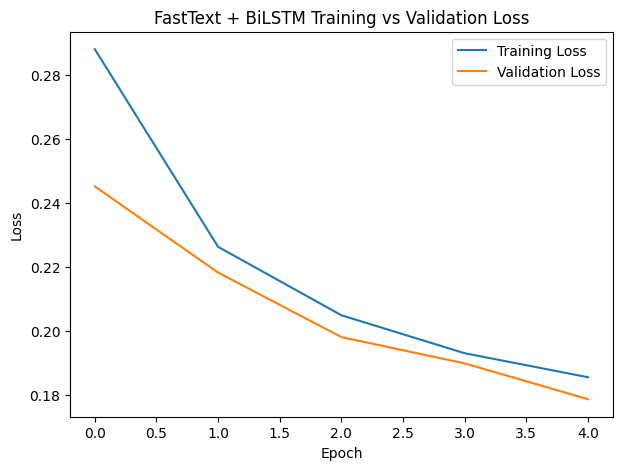

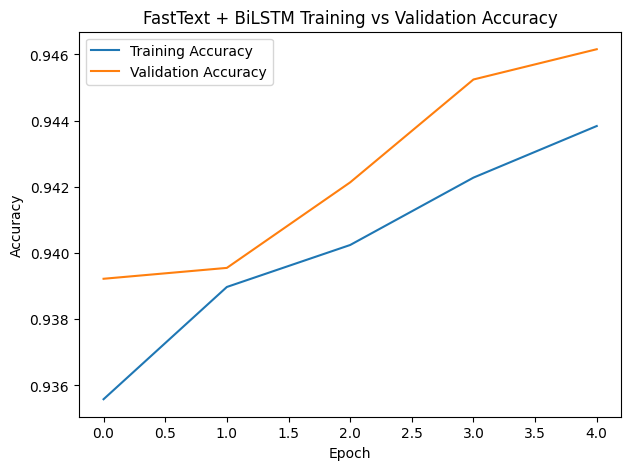

In [28]:
# ============================================================
# PLOT FASTTEXT TRAINING CURVES
# ============================================================

import matplotlib.pyplot as plt

plt.figure(figsize=(7, 5))
plt.plot(history_fasttext.history["loss"], label="Training Loss")
plt.plot(history_fasttext.history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("FastText + BiLSTM Training vs Validation Loss")
plt.legend()
plt.show()

plt.figure(figsize=(7, 5))
plt.plot(history_fasttext.history["accuracy"], label="Training Accuracy")
plt.plot(history_fasttext.history["val_accuracy"], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("FastText + BiLSTM Training vs Validation Accuracy")
plt.legend()
plt.show()

In [29]:
# ============================================================
# EVALUATE FASTTEXT MODEL
# ============================================================

fasttext_macro_f1, fasttext_weighted_f1 = evaluate_model(
    fasttext_model_bilstm,
    X_test,
    y_test,
    idx2tag
)

print("FastText Macro F1:", fasttext_macro_f1)
print("FastText Weighted F1:", fasttext_weighted_f1)

150/150 ━━━━━━━━━━━━━━━━━━━━ 15s 91ms/step
              precision    recall  f1-score   support

   B-Disease     0.5668    0.2108    0.3073      4346
   I-Disease     0.7971    0.1806    0.2944      2697
           O     0.9539    0.9948    0.9739    112494

    accuracy                         0.9479    119537
   macro avg     0.7726    0.4620    0.5252    119537
weighted avg     0.9363    0.9479    0.9343    119537

FastText Macro F1: 0.5252084543950515
FastText Weighted F1: 0.9343413673927292


In [30]:
# ============================================================
# SAVE FASTTEXT RESULT
# ============================================================

results.append({
    "Embedding": "FastText",
    "Tokenizer": "Original Dataset Tokenization",
    "Model": "BiLSTM + Softmax",
    "Macro F1": fasttext_macro_f1,
    "Weighted F1": fasttext_weighted_f1
})

results_df = pd.DataFrame(results)
results_df

,Embedding,Tokenizer,Model,Macro F1,Weighted F1
0,Trainable Embedding,Original Dataset Tokenization,BiLSTM + Softmax,0.782666,0.967972
1,Word2Vec,Original Dataset Tokenization,BiLSTM + Softmax,0.497044,0.930695
2,FastText,Original Dataset Tokenization,BiLSTM + Softmax,0.525208,0.934341


## FastText Embedding Experiment

FastText embeddings were trained using the BC5CDR training sentences. Unlike Word2Vec, FastText represents words using subword character n-grams, making it useful for rare and complex biomedical disease terms. The trained FastText vectors were used to initialize the embedding layer of a BiLSTM model. The embedding layer was kept non-trainable to compare fixed embedding performance fairly with other methods.

##GloVe + BiLSTM + Softmax

In [31]:
# ============================================================
# IMPORT GLOVE USING GENSIM DOWNLOADER
# ============================================================

import gensim.downloader as api

print("Gensim downloader imported successfully!")

Gensim downloader imported successfully!


In [32]:
# ============================================================
# LOAD PRETRAINED GLOVE EMBEDDINGS
# ============================================================

EMBEDDING_DIM = 100

glove_model = api.load("glove-wiki-gigaword-100")

print("GloVe model loaded successfully!")
print("Vector size:", glove_model.vector_size)

[==================================================] 100.0% 128.1/128.1MB downloaded
GloVe model loaded successfully!
Vector size: 100


Create GloVe embedding matrix

In [33]:
# ============================================================
# CREATE GLOVE EMBEDDING MATRIX
# ============================================================

embedding_matrix_glove = np.zeros((len(word2idx), EMBEDDING_DIM))

found_words = 0
missing_words = []

for word, idx in word2idx.items():
    if word in glove_model:
        embedding_matrix_glove[idx] = glove_model[word]
        found_words += 1
    else:
        missing_words.append(word)

print("Words found in GloVe:", found_words)
print("Total vocabulary size:", len(word2idx))
print("Coverage:", found_words / len(word2idx))
print("Embedding matrix shape:", embedding_matrix_glove.shape)

print("\nFirst 20 missing words:")
print(missing_words[:20])

Words found in GloVe: 7482
Total vocabulary size: 8741
Coverage: 0.8559661365976433
Embedding matrix shape: (8741, 100)

First 20 missing words:
['0006', '000fold', '0012', '0024', '0031', '0228', '0343', '123i', '12weeks', '139317', '17beta', '21days', '23390', '2721', '2e1', '2j', '2pam', '343499', '3504', '38393']


Build GloVe + BiLSTM model

In [34]:
# ============================================================
# BUILD GLOVE + BiLSTM MODEL
# ============================================================

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Embedding, Bidirectional, LSTM, Dense, TimeDistributed

glove_model_bilstm = Sequential([
    Input(shape=(MAX_LEN,)),

    Embedding(
        input_dim=len(word2idx),
        output_dim=EMBEDDING_DIM,
        weights=[embedding_matrix_glove],
        mask_zero=True,
        trainable=False
    ),

    Bidirectional(LSTM(
        units=64,
        return_sequences=True,
        dropout=0.3,
        recurrent_dropout=0.3
    )),

    TimeDistributed(Dense(
        len(tag2idx),
        activation="softmax"
    ))
])

glove_model_bilstm.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

glove_model_bilstm.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_3 (Embedding)         │ (None, 50, 100)        │       874,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_3 (Bidirectional) │ (None, 50, 128)        │        84,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_3              │ (None, 50, 3)          │           387 │
│ (TimeDistributed)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 958,967 (3.66 MB)

 Trainable params: 84,867 (331.51 KB)

 Non-trainable params: 874,100 (3.33 MB)

Train

In [35]:
# ============================================================
# TRAIN GLOVE + BiLSTM MODEL
# ============================================================

history_glove = glove_model_bilstm.fit(
    X_train,
    y_train_expanded,
    validation_data=(X_val, y_val_expanded),
    batch_size=32,
    epochs=5
)

Epoch 1/5
143/143 ━━━━━━━━━━━━━━━━━━━━ 80s 498ms/step - accuracy: 0.9361 - loss: 0.2218 - val_accuracy: 0.9484 - val_loss: 0.1545
Epoch 2/5
143/143 ━━━━━━━━━━━━━━━━━━━━ 69s 487ms/step - accuracy: 0.9533 - loss: 0.1441 - val_accuracy: 0.9601 - val_loss: 0.1256
Epoch 3/5
143/143 ━━━━━━━━━━━━━━━━━━━━ 70s 494ms/step - accuracy: 0.9599 - loss: 0.1248 - val_accuracy: 0.9644 - val_loss: 0.1124
Epoch 4/5
143/143 ━━━━━━━━━━━━━━━━━━━━ 70s 492ms/step - accuracy: 0.9641 - loss: 0.1134 - val_accuracy: 0.9663 - val_loss: 0.1041
Epoch 5/5
143/143 ━━━━━━━━━━━━━━━━━━━━ 71s 496ms/step - accuracy: 0.9663 - loss: 0.1045 - val_accuracy: 0.9671 - val_loss: 0.0995


Plot and Evaluate

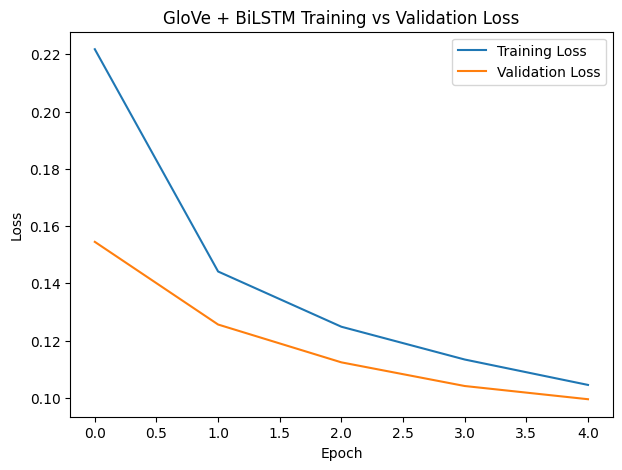

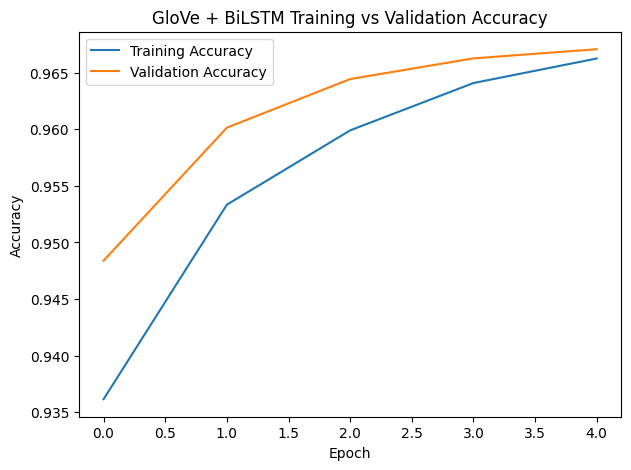

In [36]:
# ============================================================
# PLOT GLOVE TRAINING CURVES
# ============================================================

import matplotlib.pyplot as plt

plt.figure(figsize=(7, 5))
plt.plot(history_glove.history["loss"], label="Training Loss")
plt.plot(history_glove.history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("GloVe + BiLSTM Training vs Validation Loss")
plt.legend()
plt.show()

plt.figure(figsize=(7, 5))
plt.plot(history_glove.history["accuracy"], label="Training Accuracy")
plt.plot(history_glove.history["val_accuracy"], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("GloVe + BiLSTM Training vs Validation Accuracy")
plt.legend()
plt.show()

In [37]:
# ============================================================
# EVALUATE GLOVE MODEL
# ============================================================

glove_macro_f1, glove_weighted_f1 = evaluate_model(
    glove_model_bilstm,
    X_test,
    y_test,
    idx2tag
)

print("GloVe Macro F1:", glove_macro_f1)
print("GloVe Weighted F1:", glove_weighted_f1)

150/150 ━━━━━━━━━━━━━━━━━━━━ 15s 89ms/step
              precision    recall  f1-score   support

   B-Disease     0.7194    0.5833    0.6442      4346
   I-Disease     0.6896    0.6022    0.6429      2697
           O     0.9795    0.9896    0.9845    112494

    accuracy                         0.9661    119537
   macro avg     0.7961    0.7250    0.7572    119537
weighted avg     0.9635    0.9661    0.9644    119537

GloVe Macro F1: 0.757209800454826
GloVe Weighted F1: 0.9644188387215561


In [38]:
# ============================================================
# SAVE GLOVE RESULT
# ============================================================

results.append({
    "Embedding": "GloVe",
    "Tokenizer": "Original Dataset Tokenization",
    "Model": "BiLSTM + Softmax",
    "Macro F1": glove_macro_f1,
    "Weighted F1": glove_weighted_f1
})

results_df = pd.DataFrame(results)
results_df

,Embedding,Tokenizer,Model,Macro F1,Weighted F1
0,Trainable Embedding,Original Dataset Tokenization,BiLSTM + Softmax,0.782666,0.967972
1,Word2Vec,Original Dataset Tokenization,BiLSTM + Softmax,0.497044,0.930695
2,FastText,Original Dataset Tokenization,BiLSTM + Softmax,0.525208,0.934341
3,GloVe,Original Dataset Tokenization,BiLSTM + Softmax,0.757210,0.964419


In [ ]:
# ============================================================
# SHARED FUNCTIONS FOR WORD2VEC / GLOVE / FASTTEXT TOKENIZER EXPERIMENTS
# ============================================================

!pip install gensim

import numpy as np
import pandas as pd

from gensim.models import Word2Vec, FastText

from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Embedding, Bidirectional, LSTM, Dense, TimeDistributed

from sklearn.metrics import classification_report, f1_score


MAX_LEN = 50
EMBEDDING_DIM = 100
NUM_TAGS = len(tag2idx)


# ============================================================
# BASIC ENCODING FUNCTIONS
# ============================================================

def build_vocab_local(sentences):
    all_words = sorted(set(word.lower() for sent in sentences for word in sent))

    word2idx_local = {word: idx + 2 for idx, word in enumerate(all_words)}
    word2idx_local["PAD"] = 0
    word2idx_local["UNK"] = 1

    idx2word_local = {idx: word for word, idx in word2idx_local.items()}

    return word2idx_local, idx2word_local


def encode_sentences_local(sentences, word2idx_local, max_len):
    encoded = []

    for sentence in sentences:
        encoded_sentence = [
            word2idx_local.get(word.lower(), word2idx_local["UNK"])
            for word in sentence
        ]
        encoded.append(encoded_sentence)

    return pad_sequences(
        encoded,
        maxlen=max_len,
        padding="post",
        truncating="post",
        value=word2idx_local["PAD"]
    )


def encode_labels_with_mask(labels, tag2idx, max_len):
    encoded_labels = []
    masks = []

    for label_seq in labels:
        label_ids = [tag2idx[tag] for tag in label_seq]
        real_len = min(len(label_ids), max_len)

        if len(label_ids) < max_len:
            padded_labels = label_ids + [tag2idx["O"]] * (max_len - len(label_ids))
            mask = [1] * real_len + [0] * (max_len - real_len)
        else:
            padded_labels = label_ids[:max_len]
            mask = [1] * max_len

        encoded_labels.append(padded_labels)
        masks.append(mask)

    return np.array(encoded_labels), np.array(masks)


# ============================================================
# EMBEDDING MATRIX FUNCTIONS
# ============================================================

def create_word2vec_embedding_matrix(sentences, word2idx_local, embedding_dim):
    tokenized_sentences = [[word.lower() for word in sent] for sent in sentences]

    w2v_model = Word2Vec(
        sentences=tokenized_sentences,
        vector_size=embedding_dim,
        window=5,
        min_count=1,
        workers=4,
        sg=1,
        epochs=10
    )

    embedding_matrix = np.zeros((len(word2idx_local), embedding_dim))

    for word, idx in word2idx_local.items():
        if word == "PAD":
            embedding_matrix[idx] = np.zeros(embedding_dim)
        elif word in w2v_model.wv:
            embedding_matrix[idx] = w2v_model.wv[word]
        else:
            embedding_matrix[idx] = np.random.normal(scale=0.6, size=(embedding_dim,))

    return embedding_matrix


def create_fasttext_embedding_matrix(sentences, word2idx_local, embedding_dim):
    tokenized_sentences = [[word.lower() for word in sent] for sent in sentences]

    ft_model = FastText(
        sentences=tokenized_sentences,
        vector_size=embedding_dim,
        window=5,
        min_count=1,
        workers=4,
        sg=1,
        epochs=10
    )

    embedding_matrix = np.zeros((len(word2idx_local), embedding_dim))

    for word, idx in word2idx_local.items():
        if word == "PAD":
            embedding_matrix[idx] = np.zeros(embedding_dim)
        else:
            embedding_matrix[idx] = ft_model.wv[word]

    return embedding_matrix


def create_glove_embedding_matrix(word2idx_local, embedding_dim):
    # Detect your existing GloVe dictionary variable
    if "glove_embeddings_index" in globals():
        glove_dict = glove_embeddings_index
    elif "embeddings_index" in globals():
        glove_dict = embeddings_index
    elif "glove_model" in globals():
        glove_dict = glove_model
    else:
        raise NameError("No GloVe dictionary found. Check your GloVe variable name.")

    embedding_matrix = np.zeros((len(word2idx_local), embedding_dim))
    found_words = 0

    for word, idx in word2idx_local.items():
        if word == "PAD":
            embedding_matrix[idx] = np.zeros(embedding_dim)

        elif word in glove_dict:
            embedding_matrix[idx] = glove_dict[word]
            found_words += 1

        elif word.startswith("##") and word[2:] in glove_dict:
            embedding_matrix[idx] = glove_dict[word[2:]]
            found_words += 1

        else:
            embedding_matrix[idx] = np.random.normal(scale=0.6, size=(embedding_dim,))

    print(f"GloVe coverage: {found_words}/{len(word2idx_local)}")

    return embedding_matrix


# ============================================================
# MODEL + EVALUATION FUNCTIONS
# ============================================================

def build_static_bilstm_model(embedding_matrix):
    model = Sequential([
        Input(shape=(MAX_LEN,)),

        Embedding(
            input_dim=embedding_matrix.shape[0],
            output_dim=embedding_matrix.shape[1],
            weights=[embedding_matrix],
            trainable=False,
            mask_zero=False
        ),

        Bidirectional(LSTM(
            units=64,
            return_sequences=True,
            dropout=0.3,
            recurrent_dropout=0.3
        )),

        TimeDistributed(Dense(
            NUM_TAGS,
            activation="softmax"
        ))
    ])

    model.compile(
        optimizer="adam",
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model


def evaluate_static_model(model, X_test_ids, y_test_ids, test_mask, idx2tag):
    y_pred_probs = model.predict(X_test_ids)
    y_pred = np.argmax(y_pred_probs, axis=-1)

    true_tags = []
    pred_tags = []

    for i in range(y_test_ids.shape[0]):
        for j in range(y_test_ids.shape[1]):
            if test_mask[i][j] == 1:
                true_tags.append(idx2tag[y_test_ids[i][j]])
                pred_tags.append(idx2tag[y_pred[i][j]])

    print(classification_report(true_tags, pred_tags, digits=4))

    macro_f1 = f1_score(true_tags, pred_tags, average="macro", zero_division=0)
    weighted_f1 = f1_score(true_tags, pred_tags, average="weighted", zero_division=0)

    return macro_f1, weighted_f1


def run_static_embedding_tokenizer_experiment(
    embedding_name,
    train_sents,
    train_labs,
    val_sents,
    val_labs,
    test_sents,
    test_labs,
    tokenizer_name
):
    print("=" * 80)
    print(f"Running {embedding_name} + {tokenizer_name}")
    print("=" * 80)

    word2idx_local, idx2word_local = build_vocab_local(train_sents)

    X_train_local = encode_sentences_local(train_sents, word2idx_local, MAX_LEN)
    X_val_local = encode_sentences_local(val_sents, word2idx_local, MAX_LEN)
    X_test_local = encode_sentences_local(test_sents, word2idx_local, MAX_LEN)

    y_train_local, train_mask = encode_labels_with_mask(train_labs, tag2idx, MAX_LEN)
    y_val_local, val_mask = encode_labels_with_mask(val_labs, tag2idx, MAX_LEN)
    y_test_local, test_mask = encode_labels_with_mask(test_labs, tag2idx, MAX_LEN)

    if embedding_name == "Word2Vec":
        embedding_matrix = create_word2vec_embedding_matrix(
            train_sents,
            word2idx_local,
            EMBEDDING_DIM
        )

    elif embedding_name == "FastText":
        embedding_matrix = create_fasttext_embedding_matrix(
            train_sents,
            word2idx_local,
            EMBEDDING_DIM
        )

    elif embedding_name == "GloVe":
        embedding_matrix = create_glove_embedding_matrix(
            word2idx_local,
            EMBEDDING_DIM
        )

    else:
        raise ValueError("embedding_name must be Word2Vec, GloVe, or FastText")

    model = build_static_bilstm_model(embedding_matrix)

    history = model.fit(
        X_train_local,
        y_train_local,
        sample_weight=train_mask,
        validation_data=(X_val_local, y_val_local, val_mask),
        batch_size=32,
        epochs=10,
        verbose=1
    )

    macro_f1, weighted_f1 = evaluate_static_model(
        model,
        X_test_local,
        y_test_local,
        test_mask,
        idx2tag
    )

    result_df = pd.DataFrame([{
        "Embedding": embedding_name,
        "Tokenizer": tokenizer_name,
        "Model": "BiLSTM + Softmax",
        "Macro F1": macro_f1,
        "Weighted F1": weighted_f1
    }])

    return result_df, model, history

In [ ]:
# ============================================================
# RUN WORD2VEC, GLOVE, FASTTEXT WITH WORDPIECE AND NLTK
# ============================================================

# -------------------------------
# Word2Vec + WordPiece
# -------------------------------

word2vec_wordpiece_result_df, word2vec_wordpiece_model, history_word2vec_wordpiece = run_static_embedding_tokenizer_experiment(
    "Word2Vec",
    train_sentences_wp,
    train_labels_wp,
    val_sentences_wp,
    val_labels_wp,
    test_sentences_wp,
    test_labels_wp,
    tokenizer_name="BPE or WordPiece"
)

# -------------------------------
# Word2Vec + NLTK
# -------------------------------

word2vec_nltk_result_df, word2vec_nltk_model, history_word2vec_nltk = run_static_embedding_tokenizer_experiment(
    "Word2Vec",
    train_sentences_nltk,
    train_labels_nltk,
    val_sentences_nltk,
    val_labels_nltk,
    test_sentences_nltk,
    test_labels_nltk,
    tokenizer_name="NLTK"
)


# -------------------------------
# GloVe + WordPiece
# -------------------------------

glove_wordpiece_result_df, glove_wordpiece_model, history_glove_wordpiece = run_static_embedding_tokenizer_experiment(
    "GloVe",
    train_sentences_wp,
    train_labels_wp,
    val_sentences_wp,
    val_labels_wp,
    test_sentences_wp,
    test_labels_wp,
    tokenizer_name="BPE or WordPiece"
)

# -------------------------------
# GloVe + NLTK
# -------------------------------

glove_nltk_result_df, glove_nltk_model, history_glove_nltk = run_static_embedding_tokenizer_experiment(
    "GloVe",
    train_sentences_nltk,
    train_labels_nltk,
    val_sentences_nltk,
    val_labels_nltk,
    test_sentences_nltk,
    test_labels_nltk,
    tokenizer_name="NLTK"
)


# -------------------------------
# FastText + WordPiece
# -------------------------------

fasttext_wordpiece_result_df, fasttext_wordpiece_model, history_fasttext_wordpiece = run_static_embedding_tokenizer_experiment(
    "FastText",
    train_sentences_wp,
    train_labels_wp,
    val_sentences_wp,
    val_labels_wp,
    test_sentences_wp,
    test_labels_wp,
    tokenizer_name="BPE or WordPiece"
)

# -------------------------------
# FastText + NLTK
# -------------------------------

fasttext_nltk_result_df, fasttext_nltk_model, history_fasttext_nltk = run_static_embedding_tokenizer_experiment(
    "FastText",
    train_sentences_nltk,
    train_labels_nltk,
    val_sentences_nltk,
    val_labels_nltk,
    test_sentences_nltk,
    test_labels_nltk,
    tokenizer_name="NLTK"
)


# ============================================================
# ADD NEW WORD2VEC / GLOVE / FASTTEXT RESULTS TO RESULTS_DF
# ============================================================

results_df = pd.concat(
    [
        results_df,
        word2vec_wordpiece_result_df,
        word2vec_nltk_result_df,
        glove_wordpiece_result_df,
        glove_nltk_result_df,
        fasttext_wordpiece_result_df,
        fasttext_nltk_result_df
    ],
    ignore_index=True
)

results_df[["Embedding", "Tokenizer", "Macro F1", "Weighted F1"]]

# GloVe Embedding Experiment

GloVe embeddings were used as pretrained static word vectors. A 100-dimensional GloVe model trained on general English text was loaded and matched with the vocabulary of the BC5CDR dataset. The embedding matrix was used to initialize the embedding layer of a BiLSTM model. The embedding layer was kept non-trainable to fairly compare the effect of fixed GloVe embeddings.

Compared with Word2Vec and FastText trained on the biomedical dataset, GloVe may have lower vocabulary coverage because many biomedical disease terms may not appear in the general GloVe vocabulary.

##ELMo + BiLSTM + Softmax.

In [39]:
# ============================================================
# INSTALL TENSORFLOW HUB
# ============================================================

!pip install tensorflow_hub

In [40]:
# ============================================================
# IMPORT LIBRARIES FOR ELMO
# ============================================================

import tensorflow as tf
import tensorflow_hub as hub
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from tensorflow.keras.layers import Input, Bidirectional, LSTM, Dense, TimeDistributed
from tensorflow.keras.models import Model

print("TensorFlow version:", tf.__version__)
print("TensorFlow Hub imported successfully!")

TensorFlow version: 2.20.0
TensorFlow Hub imported successfully!


In [41]:
# ============================================================
# PREPARE STRING TOKEN SEQUENCES FOR ELMO
# ============================================================

def pad_token_sequences(sentences, max_len):
    padded_sentences = []

    for sentence in sentences:
        sentence_lower = [word.lower() for word in sentence]

        if len(sentence_lower) < max_len:
            sentence_lower = sentence_lower + [""] * (max_len - len(sentence_lower))
        else:
            sentence_lower = sentence_lower[:max_len]

        padded_sentences.append(sentence_lower)

    return np.array(padded_sentences, dtype=object)


X_train_elmo = pad_token_sequences(train_sentences, MAX_LEN)
X_val_elmo = pad_token_sequences(val_sentences, MAX_LEN)
X_test_elmo = pad_token_sequences(test_sentences, MAX_LEN)

print("X_train_elmo shape:", X_train_elmo.shape)
print("X_val_elmo shape:", X_val_elmo.shape)
print("X_test_elmo shape:", X_test_elmo.shape)

print(X_train_elmo[0][:25])

X_train_elmo shape: (4560, 50)
X_val_elmo shape: (4581, 50)
X_test_elmo shape: (4797, 50)
['selegiline' '-' 'induced' 'postural' 'hypotension' 'in' 'parkinson' "'"
 's' 'disease' ':' 'a' 'longitudinal' 'study' 'on' 'the' 'effects' 'of'
 'drug' 'withdrawal' '.' '' '' '' '']


In [42]:
# ============================================================
# PREPARE SEQUENCE LENGTHS FOR ELMO
# ============================================================

def get_sequence_lengths(sentences, max_len):
    return np.array([min(len(sentence), max_len) for sentence in sentences], dtype=np.int32)


train_seq_lens = get_sequence_lengths(train_sentences, MAX_LEN)
val_seq_lens = get_sequence_lengths(val_sentences, MAX_LEN)
test_seq_lens = get_sequence_lengths(test_sentences, MAX_LEN)

print("train_seq_lens shape:", train_seq_lens.shape)
print("First 10 sequence lengths:", train_seq_lens[:10])

train_seq_lens shape: (4560,)
First 10 sequence lengths: [21 50 27 16 49 27 32 10 21 21]


In [43]:
# ============================================================
# LOAD ELMO MODEL
# ============================================================

import tensorflow as tf
import tensorflow_hub as hub
import numpy as np

elmo = hub.load("https://tfhub.dev/google/elmo/3")

print("ELMo loaded successfully!")

ELMo loaded successfully!


Build ELMo + BiLSTM model

In [44]:
# ============================================================
# SAFE PREPARE STRING TOKEN SEQUENCES FOR ELMO
# ============================================================

def pad_token_sequences(sentences, max_len):
    padded_sentences = []

    for sentence in sentences:

        # If sentence is empty, add one dummy token
        if len(sentence) == 0:
            sentence_lower = ["<PAD>"]
        else:
            sentence_lower = [str(word).lower() for word in sentence]

        if len(sentence_lower) < max_len:
            sentence_lower = sentence_lower + ["<PAD>"] * (max_len - len(sentence_lower))
        else:
            sentence_lower = sentence_lower[:max_len]

        padded_sentences.append(sentence_lower)

    return np.array(padded_sentences, dtype=str)


def get_sequence_lengths(sentences, max_len):
    seq_lens = []

    for sentence in sentences:
        length = min(len(sentence), max_len)

        # ELMo cannot accept sequence length 0
        if length == 0:
            length = 1

        seq_lens.append(length)

    return np.array(seq_lens, dtype=np.int32)

In [45]:
# ============================================================
# CHECK EMPTY SENTENCES before elmo
# ============================================================

empty_indices = [i for i, sent in enumerate(train_sentences[:32]) if len(sent) == 0]

print("Empty sentence indices in first 32:", empty_indices)

for i in empty_indices:
    print(i, train_sentences[i])

Empty sentence indices in first 32: []


In [46]:
# ============================================================
# RECREATE ELMO INPUTS
# ============================================================

X_train_elmo = pad_token_sequences(train_sentences, MAX_LEN)
X_val_elmo = pad_token_sequences(val_sentences, MAX_LEN)
X_test_elmo = pad_token_sequences(test_sentences, MAX_LEN)

train_seq_lens = get_sequence_lengths(train_sentences, MAX_LEN)
val_seq_lens = get_sequence_lengths(val_sentences, MAX_LEN)
test_seq_lens = get_sequence_lengths(test_sentences, MAX_LEN)

print("X_train_elmo shape:", X_train_elmo.shape)
print("train_seq_lens shape:", train_seq_lens.shape)

print("Minimum train sequence length:", train_seq_lens.min())
print("Maximum train sequence length:", train_seq_lens.max())
print("Example sentence:", X_train_elmo[0][:20])

X_train_elmo shape: (4560, 50)
train_seq_lens shape: (4560,)
Minimum train sequence length: 2
Maximum train sequence length: 50
Example sentence: ['selegiline' '-' 'induced' 'postural' 'hypotension' 'in' 'parkinson' "'"
 's' 'disease' ':' 'a' 'longitudinal' 'study' 'on' 'the' 'effects' 'of'
 'drug' 'withdrawal']


In [47]:
# ============================================================
# GENERATE ELMO EMBEDDINGS IN BATCHES - SAFE VERSION
# ============================================================

def generate_elmo_embeddings(tokens_array, seq_lens_array, batch_size=8):
    all_embeddings = []

    for start in range(0, len(tokens_array), batch_size):
        end = min(start + batch_size, len(tokens_array))

        batch_tokens = tf.constant(tokens_array[start:end], dtype=tf.string)
        batch_seq_lens = tf.constant(seq_lens_array[start:end], dtype=tf.int32)

        try:
            outputs = elmo.signatures["tokens"](
                tokens=batch_tokens,
                sequence_len=batch_seq_lens
            )

            batch_embeddings = outputs["elmo"].numpy()
            all_embeddings.append(batch_embeddings)

            print(f"Processed {end}/{len(tokens_array)}")

        except Exception as e:
            print(f"Error in batch {start}:{end}")
            print("Batch sequence lengths:", seq_lens_array[start:end])
            print("Batch tokens sample:", tokens_array[start])
            raise e

    return np.vstack(all_embeddings)

In [48]:
# ============================================================
# FIXED ELMO EMBEDDING GENERATION FUNCTION
# Handles ELMo shape mismatch by trimming batch then padding back
# ============================================================

def generate_elmo_embeddings_fixed(tokens_array, seq_lens_array, max_len, batch_size=8):
    all_embeddings = []

    for start in range(0, len(tokens_array), batch_size):
        end = min(start + batch_size, len(tokens_array))

        batch_tokens_full = tokens_array[start:end]
        batch_seq_lens = seq_lens_array[start:end]

        # Get maximum real sentence length in this batch
        batch_max_len = int(np.max(batch_seq_lens))

        # Trim tokens to batch maximum length
        batch_tokens_trimmed = batch_tokens_full[:, :batch_max_len]

        batch_tokens_tensor = tf.constant(batch_tokens_trimmed, dtype=tf.string)
        batch_seq_lens_tensor = tf.constant(batch_seq_lens, dtype=tf.int32)

        outputs = elmo.signatures["tokens"](
            tokens=batch_tokens_tensor,
            sequence_len=batch_seq_lens_tensor
        )

        batch_embeddings = outputs["elmo"].numpy()

        # Pad embeddings back to MAX_LEN
        current_len = batch_embeddings.shape[1]

        if current_len < max_len:
            pad_width = max_len - current_len

            padding = np.zeros(
                (batch_embeddings.shape[0], pad_width, batch_embeddings.shape[2]),
                dtype=batch_embeddings.dtype
            )

            batch_embeddings = np.concatenate(
                [batch_embeddings, padding],
                axis=1
            )

        elif current_len > max_len:
            batch_embeddings = batch_embeddings[:, :max_len, :]

        all_embeddings.append(batch_embeddings)

        print(f"Processed {end}/{len(tokens_array)} | batch_max_len={batch_max_len}")

    return np.vstack(all_embeddings)

In [49]:
# ============================================================
# TEST FIXED ELMO EMBEDDING GENERATION
# ============================================================

test_elmo_emb = generate_elmo_embeddings_fixed(
    X_train_elmo[:32],
    train_seq_lens[:32],
    max_len=MAX_LEN,
    batch_size=8
)

print("Test ELMo embedding shape:", test_elmo_emb.shape)

Processed 8/32 | batch_max_len=50
Processed 16/32 | batch_max_len=26
Processed 24/32 | batch_max_len=50
Processed 32/32 | batch_max_len=31
Test ELMo embedding shape: (32, 50, 1024)


In [50]:
# ============================================================
# CREATE FULL ELMO EMBEDDINGS
# ============================================================

X_train_elmo_emb = generate_elmo_embeddings_fixed(
    X_train_elmo,
    train_seq_lens,
    max_len=MAX_LEN,
    batch_size=8
)

X_val_elmo_emb = generate_elmo_embeddings_fixed(
    X_val_elmo,
    val_seq_lens,
    max_len=MAX_LEN,
    batch_size=8
)

X_test_elmo_emb = generate_elmo_embeddings_fixed(
    X_test_elmo,
    test_seq_lens,
    max_len=MAX_LEN,
    batch_size=8
)

print("ELMo train embeddings:", X_train_elmo_emb.shape)
print("ELMo val embeddings:", X_val_elmo_emb.shape)
print("ELMo test embeddings:", X_test_elmo_emb.shape)

Processed 8/4560 | batch_max_len=50
Processed 16/4560 | batch_max_len=26
Processed 24/4560 | batch_max_len=50
Processed 32/4560 | batch_max_len=31
Processed 40/4560 | batch_max_len=35
Processed 48/4560 | batch_max_len=33
Processed 56/4560 | batch_max_len=39
Processed 64/4560 | batch_max_len=43
Processed 72/4560 | batch_max_len=42
Processed 80/4560 | batch_max_len=41
Processed 88/4560 | batch_max_len=50
Processed 96/4560 | batch_max_len=50
Processed 104/4560 | batch_max_len=50
Processed 112/4560 | batch_max_len=45
Processed 120/4560 | batch_max_len=33
Processed 128/4560 | batch_max_len=48
Processed 136/4560 | batch_max_len=39
Processed 144/4560 | batch_max_len=50
Processed 152/4560 | batch_max_len=50
Processed 160/4560 | batch_max_len=50
Processed 168/4560 | batch_max_len=46
Processed 176/4560 | batch_max_len=50
Processed 184/4560 | batch_max_len=50
Processed 192/4560 | batch_max_len=41
Processed 200/4560 | batch_max_len=39
Processed 208/4560 | batch_max_len=50
Processed 216/4560 | batc

In [51]:
# ============================================================
# CHECK EMBEDDING AND LABEL SHAPES
# ============================================================

print("X_train_elmo_emb:", X_train_elmo_emb.shape)
print("X_val_elmo_emb:", X_val_elmo_emb.shape)
print("X_test_elmo_emb:", X_test_elmo_emb.shape)

print("y_train:", y_train.shape)
print("y_val:", y_val.shape)
print("y_test:", y_test.shape)

print("Number of tags:", len(tag2idx))
print("tag2idx:", tag2idx)

X_train_elmo_emb: (4560, 50, 1024)
X_val_elmo_emb: (4581, 50, 1024)
X_test_elmo_emb: (4797, 50, 1024)
y_train: (4560, 50)
y_val: (4581, 50)
y_test: (4797, 50)
Number of tags: 3
tag2idx: {'O': 0, 'B-Disease': 1, 'I-Disease': 2}


Train

In [52]:
# ============================================================
# BUILD ELMO + BiLSTM + SOFTMAX MODEL
# ============================================================

from tensorflow.keras.layers import Input, Bidirectional, LSTM, Dense, TimeDistributed, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam

ELMO_DIM = 1024
NUM_TAGS = len(tag2idx)

input_layer = Input(shape=(MAX_LEN, ELMO_DIM), name="elmo_embeddings")

x = Bidirectional(
    LSTM(
        units=128,
        return_sequences=True,
        dropout=0.3,
        recurrent_dropout=0.3
    )
)(input_layer)

x = Dropout(0.3)(x)

output_layer = TimeDistributed(
    Dense(NUM_TAGS, activation="softmax")
)(x)

elmo_bilstm_model = Model(
    inputs=input_layer,
    outputs=output_layer
)

elmo_bilstm_model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

elmo_bilstm_model.summary()

Model: "functional_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ elmo_embeddings (InputLayer)    │ (None, 50, 1024)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_4 (Bidirectional) │ (None, 50, 256)        │     1,180,672 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 50, 256)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_4              │ (None, 50, 3)          │           771 │
│ (TimeDistributed)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,181,443 (4.51 MB)

 Trainable params: 1,181,443 (4.51 MB)

 Non-trainable params: 0 (0.00 B)

In [53]:
# ============================================================
# TRAIN ELMO + BiLSTM + SOFTMAX MODEL
# ============================================================

from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=2,
    min_lr=1e-6
)

history_elmo = elmo_bilstm_model.fit(
    X_train_elmo_emb,
    y_train,
    validation_data=(X_val_elmo_emb, y_val),
    batch_size=16,
    epochs=10,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

Epoch 1/10
285/285 ━━━━━━━━━━━━━━━━━━━━ 87s 286ms/step - accuracy: 0.9790 - loss: 0.0658 - val_accuracy: 0.9846 - val_loss: 0.0442 - learning_rate: 0.0010
Epoch 2/10
285/285 ━━━━━━━━━━━━━━━━━━━━ 78s 273ms/step - accuracy: 0.9870 - loss: 0.0379 - val_accuracy: 0.9870 - val_loss: 0.0373 - learning_rate: 0.0010
Epoch 3/10
285/285 ━━━━━━━━━━━━━━━━━━━━ 79s 264ms/step - accuracy: 0.9888 - loss: 0.0313 - val_accuracy: 0.9853 - val_loss: 0.0399 - learning_rate: 0.0010
Epoch 4/10
285/285 ━━━━━━━━━━━━━━━━━━━━ 83s 266ms/step - accuracy: 0.9906 - loss: 0.0261 - val_accuracy: 0.9882 - val_loss: 0.0345 - learning_rate: 0.0010
Epoch 5/10
285/285 ━━━━━━━━━━━━━━━━━━━━ 96s 337ms/step - accuracy: 0.9927 - loss: 0.0209 - val_accuracy: 0.9886 - val_loss: 0.0336 - learning_rate: 0.0010
Epoch 6/10
285/285 ━━━━━━━━━━━━━━━━━━━━ 75s 265ms/step - accuracy: 0.9937 - loss: 0.0176 - val_accuracy: 0.9887 - val_loss: 0.0352 - learning_rate: 0.0010
Epoch 7/10
285/285 ━━━━━━━━━━━━━━━━━━━━ 83s 268ms/step - accuracy: 0.9

Plot and Evaluate

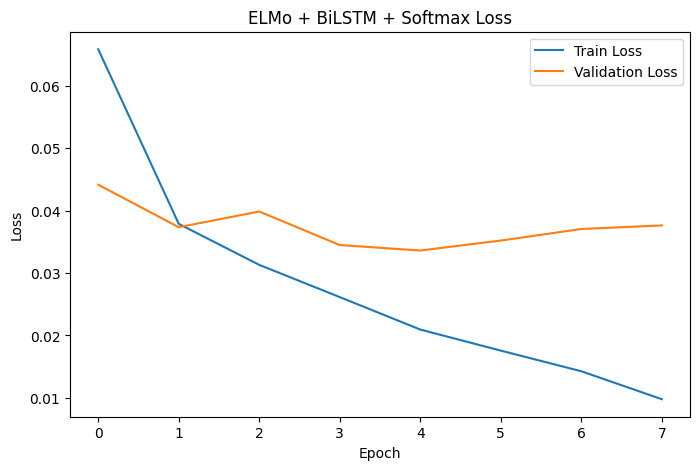

In [54]:
# ============================================================
# PLOT TRAINING LOSS
# ============================================================

import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.plot(history_elmo.history["loss"], label="Train Loss")
plt.plot(history_elmo.history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("ELMo + BiLSTM + Softmax Loss")
plt.legend()
plt.show()

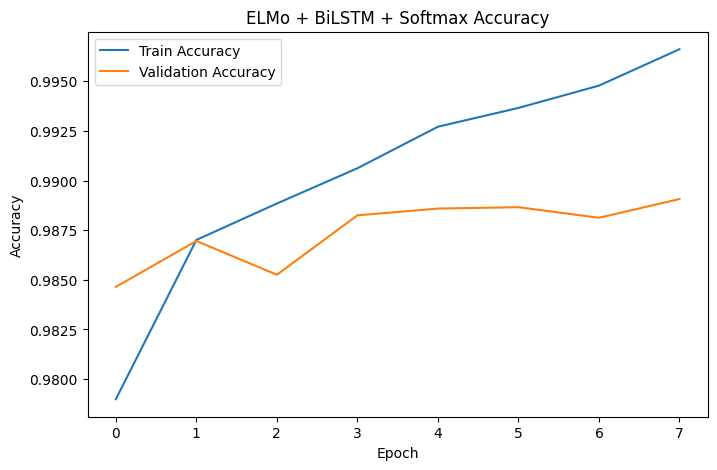

In [55]:
# ============================================================
# PLOT TRAINING ACCURACY
# ============================================================

plt.figure(figsize=(8, 5))
plt.plot(history_elmo.history["accuracy"], label="Train Accuracy")
plt.plot(history_elmo.history["val_accuracy"], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("ELMo + BiLSTM + Softmax Accuracy")
plt.legend()
plt.show()

In [56]:
# ============================================================
# EVALUATE ON TEST SET
# ============================================================

test_loss, test_accuracy = elmo_bilstm_model.evaluate(
    X_test_elmo_emb,
    y_test,
    verbose=1
)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

150/150 ━━━━━━━━━━━━━━━━━━━━ 12s 79ms/step - accuracy: 0.9888 - loss: 0.0324
Test Loss: 0.03235364332795143
Test Accuracy: 0.9888470768928528


In [57]:
# ============================================================
# MAKE PREDICTIONS
# ============================================================

y_pred_probs = elmo_bilstm_model.predict(X_test_elmo_emb)

y_pred = np.argmax(y_pred_probs, axis=-1)

print("y_pred shape:", y_pred.shape)
print("y_test shape:", y_test.shape)

150/150 ━━━━━━━━━━━━━━━━━━━━ 14s 87ms/step
y_pred shape: (4797, 50)
y_test shape: (4797, 50)


In [58]:
# ============================================================
# REMOVE PAD TOKENS FOR PROPER NER EVALUATION
# ============================================================

from sklearn.metrics import classification_report, f1_score

# Make sure idx2tag exists
idx2tag = {idx: tag for tag, idx in tag2idx.items()}

pad_idx = tag2idx.get("PAD", None)

true_labels = []
pred_labels = []

for i in range(len(y_test)):
    for j in range(MAX_LEN):

        true_id = y_test[i][j]
        pred_id = y_pred[i][j]

        # Ignore PAD tokens
        if pad_idx is not None and true_id == pad_idx:
            continue

        true_labels.append(idx2tag[true_id])
        pred_labels.append(idx2tag[pred_id])

print("Number of evaluated tokens:", len(true_labels))
print("Example true labels:", true_labels[:20])
print("Example predicted labels:", pred_labels[:20])

Number of evaluated tokens: 239850
Example true labels: ['B-Disease', 'I-Disease', 'I-Disease', 'B-Disease', 'I-Disease', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'B-Disease', 'I-Disease', 'O', 'B-Disease', 'I-Disease']
Example predicted labels: ['O', 'I-Disease', 'I-Disease', 'B-Disease', 'I-Disease', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'B-Disease', 'I-Disease', 'O', 'B-Disease', 'I-Disease']


In [59]:
# ============================================================
# CLASSIFICATION REPORT
# ============================================================

print("ELMo + BiLSTM + Softmax Classification Report")
print(classification_report(true_labels, pred_labels, digits=4))

# ============================================================
# CALCULATE F1 SCORES
# ============================================================

elmo_macro_f1 = f1_score(true_labels, pred_labels, average="macro")
elmo_weighted_f1 = f1_score(true_labels, pred_labels, average="weighted")

print("ELMo + BiLSTM + Softmax Macro F1:", elmo_macro_f1)
print("ELMo + BiLSTM + Softmax Weighted F1:", elmo_weighted_f1)

ELMo + BiLSTM + Softmax Classification Report
              precision    recall  f1-score   support

   B-Disease     0.8281    0.7701    0.7980      4346
   I-Disease     0.7347    0.7475    0.7410      2697
           O     0.9946    0.9957    0.9952    232807

    accuracy                         0.9888    239850
   macro avg     0.8525    0.8378    0.8448    239850
weighted avg     0.9887    0.9888    0.9887    239850

ELMo + BiLSTM + Softmax Macro F1: 0.8447539507665476
ELMo + BiLSTM + Softmax Weighted F1: 0.9887471676126802


In [130]:
    # ============================================================
    # EVALUATE ELMO MODEL USING F1-SCORE
    # ============================================================

    from sklearn.metrics import classification_report, f1_score

    def evaluate_elmo_model(model, X_tokens, X_seq_lens, X_original_ids, y_true, idx2tag):
        # The elmo_bilstm_model expects only X_tokens (elmo embeddings) as input
        predictions = model.predict(X_tokens)
        y_pred = np.argmax(predictions, axis=-1)

        true_tags = []
        pred_tags = []

        for i in range(y_true.shape[0]):
            for j in range(y_true.shape[1]):

                # Ignore padding positions. Here, X_original_ids (X_test) still corresponds
                # to the original token IDs and contains 'PAD' values.
                if X_original_ids[i][j] != word2idx["PAD"]:
                    true_tags.append(idx2tag[y_true[i][j]])
                    pred_tags.append(idx2tag[y_pred[i][j]])

        print(classification_report(true_tags, pred_tags, digits=4))

        macro_f1 = f1_score(true_tags, pred_tags, average="macro")
        weighted_f1 = f1_score(true_tags, pred_tags, average="weighted")

        return macro_f1, weighted_f1


    elmo_macro_f1, elmo_weighted_f1 = evaluate_elmo_model(
        elmo_bilstm_model,
        X_test_elmo_emb,
        test_seq_lens,
        X_test,
        y_test,
        idx2tag
    )

    print("ELMo Macro F1:", elmo_macro_f1)
    print("ELMo Weighted F1:", elmo_weighted_f1)

150/150 ━━━━━━━━━━━━━━━━━━━━ 11s 76ms/step
              precision    recall  f1-score   support

   B-Disease     0.9889    0.9912    0.9900    112494
   I-Disease     0.8281    0.7701    0.7980      4346
           O     0.7347    0.7475    0.7410      2697

    accuracy                         0.9776    119537
   macro avg     0.8505    0.8363    0.8430    119537
weighted avg     0.9773    0.9776    0.9774    119537

ELMo Macro F1: 0.8430364239238255
ELMo Weighted F1: 0.9774268239833626


In [131]:
# ============================================================
# SAVE ELMO RESULT FOR FINAL COMPARISON TABLE
# ============================================================

elmo_result = {
    "Embedding": "ELMo",
    "Tokenizer": "Whitespace",
    "Model": "BiLSTM + Softmax",
    "Test Accuracy": test_accuracy,
    "Macro F1": elmo_macro_f1,
    "Weighted F1": elmo_weighted_f1
}

elmo_result_df = pd.DataFrame([elmo_result])
elmo_result_df


# ============================================================
#  SAVE MODEL
# ============================================================

elmo_bilstm_model.save("elmo_bilstm_softmax_model.h5")

print("Model saved successfully!")

Model saved successfully!


In [132]:
# ============================================================
# PREDICT USING ELMO MODEL
# ============================================================

y_pred_probs = elmo_bilstm_model.predict(X_test_elmo_emb)
y_pred = np.argmax(y_pred_probs, axis=-1)

print("y_pred shape:", y_pred.shape)
print("y_test shape:", y_test.shape)

150/150 ━━━━━━━━━━━━━━━━━━━━ 12s 81ms/step
y_pred shape: (4797, 50)
y_test shape: (4797, 50)


In [133]:
elmo_result = {
    "Embedding": "ELMo",
    "Tokenizer": "Whitespace",
    "Model": "BiLSTM + Softmax",
    "Macro F1": elmo_macro_f1,
    "Weighted F1": elmo_weighted_f1
}

elmo_result_df = pd.DataFrame([elmo_result])
elmo_result_df.to_csv("/content/drive/MyDrive/elmo_result.csv", index=False)

print("ELMo result saved.")

ELMo result saved.


In [134]:
# ============================================================
# ADD ELMO TO RESULTS_DF
# ============================================================

results_df = pd.concat(
    [results_df, elmo_result_df],
    ignore_index=True
)

results_df[["Embedding", "Tokenizer", "Macro F1", "Weighted F1"]]

,Embedding,Tokenizer,Macro F1,Weighted F1
0,Trainable Embedding,Original Dataset Tokenization,0.782666,0.967972
1,GloVe,Original Dataset Tokenization,0.757210,0.964419
2,FastText,Original Dataset Tokenization,0.525208,0.934341
3,Word2Vec,Original Dataset Tokenization,0.497044,0.930695
4,BERT,WordPiece,0.858024,0.980033
5,ELMo,Whitespace,0.843036,0.977427


In [135]:
# ============================================================
# SAVE ELMO MODEL
# ============================================================

elmo_bilstm_model.save("elmo_bilstm_softmax_model.h5")

print("ELMo model saved successfully!")

ELMo model saved successfully!


In [150]:
# ============================================================
# HELPER FUNCTIONS FOR ELMO TOKENIZER EXPERIMENTS
# ============================================================

import numpy as np
import pandas as pd
import tensorflow as tf
from sklearn.metrics import classification_report, f1_score
from tensorflow.keras.layers import Input, Bidirectional, LSTM, Dense, TimeDistributed, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam

MAX_LEN = 50
ELMO_DIM = 1024
NUM_TAGS = len(tag2idx)

def pad_tokens_for_elmo(sentences, max_len):
    padded_sentences = []
    seq_lens = []

    for sentence in sentences:
        sentence = [str(w).lower() for w in sentence]

        length = min(len(sentence), max_len)
        seq_lens.append(max(length, 1))

        if len(sentence) < max_len:
            sentence = sentence + ["<PAD>"] * (max_len - len(sentence))
        else:
            sentence = sentence[:max_len]

        padded_sentences.append(sentence)

    return np.array(padded_sentences, dtype=str), np.array(seq_lens, dtype=np.int32)


def pad_labels_for_elmo(labels, tag2idx, max_len):
    padded_labels = []
    masks = []

    for label_seq in labels:
        label_ids = [tag2idx[tag] for tag in label_seq]

        real_len = min(len(label_ids), max_len)

        if len(label_ids) < max_len:
            padded = label_ids + [tag2idx["O"]] * (max_len - len(label_ids))
            mask = [1] * real_len + [0] * (max_len - real_len)
        else:
            padded = label_ids[:max_len]
            mask = [1] * max_len

        padded_labels.append(padded)
        masks.append(mask)

    return np.array(padded_labels), np.array(masks)


def build_elmo_bilstm_model():
    input_layer = Input(shape=(MAX_LEN, ELMO_DIM), name="elmo_input")

    x = Bidirectional(
        LSTM(
            units=128,
            return_sequences=True,
            dropout=0.3,
            recurrent_dropout=0.3
        )
    )(input_layer)

    x = Dropout(0.3)(x)

    output_layer = TimeDistributed(
        Dense(NUM_TAGS, activation="softmax")
    )(x)

    model = Model(inputs=input_layer, outputs=output_layer)

    model.compile(
        optimizer=Adam(learning_rate=0.001),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model


def evaluate_elmo_tokenizer_model(model, X_test_emb, y_test_ids, test_mask, idx2tag):
    y_pred_probs = model.predict(X_test_emb)
    y_pred = np.argmax(y_pred_probs, axis=-1)

    true_tags = []
    pred_tags = []

    for i in range(y_test_ids.shape[0]):
        for j in range(y_test_ids.shape[1]):
            if test_mask[i][j] == 1:
                true_tags.append(idx2tag[y_test_ids[i][j]])
                pred_tags.append(idx2tag[y_pred[i][j]])

    print(classification_report(true_tags, pred_tags, digits=4))

    macro_f1 = f1_score(true_tags, pred_tags, average="macro")
    weighted_f1 = f1_score(true_tags, pred_tags, average="weighted")

    return macro_f1, weighted_f1

ELMO + WORDPIECE

In [151]:
# ============================================================
# CREATE WORDPIECE TOKENIZED DATA FOR ELMO
# ============================================================

from transformers import AutoTokenizer

wordpiece_tokenizer = AutoTokenizer.from_pretrained("bert-base-cased")

def wordpiece_tokenize_with_labels(sentences, labels):
    new_sentences = []
    new_labels = []

    for sent, label_seq in zip(sentences, labels):
        wp_sent = []
        wp_labels = []

        for word, tag in zip(sent, label_seq):
            pieces = wordpiece_tokenizer.tokenize(word)

            if len(pieces) == 0:
                continue

            for i, piece in enumerate(pieces):
                wp_sent.append(piece)

                if i == 0:
                    wp_labels.append(tag)
                else:
                    if tag == "B-Disease":
                        wp_labels.append("I-Disease")
                    else:
                        wp_labels.append(tag)

        new_sentences.append(wp_sent)
        new_labels.append(wp_labels)

    return new_sentences, new_labels


train_sentences_wp, train_labels_wp = wordpiece_tokenize_with_labels(train_sentences, train_labels)
val_sentences_wp, val_labels_wp = wordpiece_tokenize_with_labels(val_sentences, val_labels)
test_sentences_wp, test_labels_wp = wordpiece_tokenize_with_labels(test_sentences, test_labels)

print("WordPiece train sentences:", len(train_sentences_wp))
print("Example:", train_sentences_wp[0])
print("Labels:", train_labels_wp[0])

WordPiece train sentences: 4560
Example: ['Se', '##leg', '##ili', '##ne', '-', 'induced', 'post', '##ural', 'h', '##y', '##pot', '##ens', '##ion', 'in', 'Parkinson', "'", 's', 'disease', ':', 'a', 'longitudinal', 'study', 'on', 'the', 'effects', 'of', 'drug', 'withdrawal', '.']
Labels: ['O', 'O', 'O', 'O', 'O', 'O', 'B-Disease', 'I-Disease', 'I-Disease', 'I-Disease', 'I-Disease', 'I-Disease', 'I-Disease', 'O', 'B-Disease', 'I-Disease', 'I-Disease', 'I-Disease', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O']


In [ ]:
# ============================================================
# ELMO + WORDPIECE EXPERIMENT
# ============================================================

X_train_wp_elmo, train_wp_seq_lens = pad_tokens_for_elmo(train_sentences_wp, MAX_LEN)
X_val_wp_elmo, val_wp_seq_lens = pad_tokens_for_elmo(val_sentences_wp, MAX_LEN)
X_test_wp_elmo, test_wp_seq_lens = pad_tokens_for_elmo(test_sentences_wp, MAX_LEN)

y_train_wp, train_wp_mask = pad_labels_for_elmo(train_labels_wp, tag2idx, MAX_LEN)
y_val_wp, val_wp_mask = pad_labels_for_elmo(val_labels_wp, tag2idx, MAX_LEN)
y_test_wp, test_wp_mask = pad_labels_for_elmo(test_labels_wp, tag2idx, MAX_LEN)

X_train_wp_elmo_emb = generate_elmo_embeddings_fixed(
    X_train_wp_elmo,
    train_wp_seq_lens,
    max_len=MAX_LEN,
    batch_size=8
)

X_val_wp_elmo_emb = generate_elmo_embeddings_fixed(
    X_val_wp_elmo,
    val_wp_seq_lens,
    max_len=MAX_LEN,
    batch_size=8
)

X_test_wp_elmo_emb = generate_elmo_embeddings_fixed(
    X_test_wp_elmo,
    test_wp_seq_lens,
    max_len=MAX_LEN,
    batch_size=8
)

elmo_wordpiece_model = build_elmo_bilstm_model()

history_elmo_wordpiece = elmo_wordpiece_model.fit(
    X_train_wp_elmo_emb,
    y_train_wp,
    sample_weight=train_wp_mask,
    validation_data=(X_val_wp_elmo_emb, y_val_wp, val_wp_mask),
    batch_size=16,
    epochs=10,
    verbose=1
)

elmo_wp_macro_f1, elmo_wp_weighted_f1 = evaluate_elmo_tokenizer_model(
    elmo_wordpiece_model,
    X_test_wp_elmo_emb,
    y_test_wp,
    test_wp_mask,
    idx2tag
)

print("ELMo + WordPiece Macro F1:", elmo_wp_macro_f1)
print("ELMo + WordPiece Weighted F1:", elmo_wp_weighted_f1)

Processed 8/4560 | batch_max_len=50
Processed 16/4560 | batch_max_len=42
Processed 24/4560 | batch_max_len=50
Processed 32/4560 | batch_max_len=35
Processed 40/4560 | batch_max_len=50
Processed 48/4560 | batch_max_len=45
Processed 56/4560 | batch_max_len=50
Processed 64/4560 | batch_max_len=50
Processed 72/4560 | batch_max_len=47
Processed 80/4560 | batch_max_len=50
Processed 88/4560 | batch_max_len=50
Processed 96/4560 | batch_max_len=50
Processed 104/4560 | batch_max_len=50
Processed 112/4560 | batch_max_len=50
Processed 120/4560 | batch_max_len=43
Processed 128/4560 | batch_max_len=50
Processed 136/4560 | batch_max_len=50
Processed 144/4560 | batch_max_len=50
Processed 152/4560 | batch_max_len=50
Processed 160/4560 | batch_max_len=50
Processed 168/4560 | batch_max_len=50
Processed 176/4560 | batch_max_len=50
Processed 184/4560 | batch_max_len=50
Processed 192/4560 | batch_max_len=47
Processed 200/4560 | batch_max_len=50
Processed 208/4560 | batch_max_len=50
Processed 216/4560 | batc

In [ ]:
# ============================================================
# CREATE NLTK TOKENIZED DATA FOR ELMO
# ============================================================

!pip install nltk

import nltk
nltk.download("punkt")
nltk.download("punkt_tab")

from nltk.tokenize import word_tokenize

def nltk_tokenize_with_labels(sentences, labels):
    new_sentences = []
    new_labels = []

    for sent, label_seq in zip(sentences, labels):
        nltk_sent = []
        nltk_labels = []

        for word, tag in zip(sent, label_seq):
            pieces = word_tokenize(word)

            if len(pieces) == 0:
                continue

            for i, piece in enumerate(pieces):
                nltk_sent.append(piece)

                if i == 0:
                    nltk_labels.append(tag)
                else:
                    if tag == "B-Disease":
                        nltk_labels.append("I-Disease")
                    else:
                        nltk_labels.append(tag)

        new_sentences.append(nltk_sent)
        new_labels.append(nltk_labels)

    return new_sentences, new_labels


train_sentences_nltk, train_labels_nltk = nltk_tokenize_with_labels(train_sentences, train_labels)
val_sentences_nltk, val_labels_nltk = nltk_tokenize_with_labels(val_sentences, val_labels)
test_sentences_nltk, test_labels_nltk = nltk_tokenize_with_labels(test_sentences, test_labels)

print("NLTK train sentences:", len(train_sentences_nltk))
print("Example:", train_sentences_nltk[0])
print("Labels:", train_labels_nltk[0])

In [ ]:
# ============================================================
# ELMO + NLTK EXPERIMENT
# ============================================================

X_train_nltk_elmo, train_nltk_seq_lens = pad_tokens_for_elmo(train_sentences_nltk, MAX_LEN)
X_val_nltk_elmo, val_nltk_seq_lens = pad_tokens_for_elmo(val_sentences_nltk, MAX_LEN)
X_test_nltk_elmo, test_nltk_seq_lens = pad_tokens_for_elmo(test_sentences_nltk, MAX_LEN)

y_train_nltk, train_nltk_mask = pad_labels_for_elmo(train_labels_nltk, tag2idx, MAX_LEN)
y_val_nltk, val_nltk_mask = pad_labels_for_elmo(val_labels_nltk, tag2idx, MAX_LEN)
y_test_nltk, test_nltk_mask = pad_labels_for_elmo(test_labels_nltk, tag2idx, MAX_LEN)

X_train_nltk_elmo_emb = generate_elmo_embeddings_fixed(
    X_train_nltk_elmo,
    train_nltk_seq_lens,
    max_len=MAX_LEN,
    batch_size=8
)

X_val_nltk_elmo_emb = generate_elmo_embeddings_fixed(
    X_val_nltk_elmo,
    val_nltk_seq_lens,
    max_len=MAX_LEN,
    batch_size=8
)

X_test_nltk_elmo_emb = generate_elmo_embeddings_fixed(
    X_test_nltk_elmo,
    test_nltk_seq_lens,
    max_len=MAX_LEN,
    batch_size=8
)

elmo_nltk_model = build_elmo_bilstm_model()

history_elmo_nltk = elmo_nltk_model.fit(
    X_train_nltk_elmo_emb,
    y_train_nltk,
    sample_weight=train_nltk_mask,
    validation_data=(X_val_nltk_elmo_emb, y_val_nltk, val_nltk_mask),
    batch_size=16,
    epochs=10,
    verbose=1
)

elmo_nltk_macro_f1, elmo_nltk_weighted_f1 = evaluate_elmo_tokenizer_model(
    elmo_nltk_model,
    X_test_nltk_elmo_emb,
    y_test_nltk,
    test_nltk_mask,
    idx2tag
)

print("ELMo + NLTK Macro F1:", elmo_nltk_macro_f1)
print("ELMo + NLTK Weighted F1:", elmo_nltk_weighted_f1)

#### ELMo Embedding Experiment

ELMo was used as a contextual embedding method for the BC5CDR disease NER task. Tokenized biomedical sentences were passed through the pretrained ELMo model to generate 1024-dimensional embeddings for each token. These embeddings were then used as input to a BiLSTM model followed by a Softmax classification layer to predict BIO tags. Since ELMo is context-dependent, it can capture different meanings of the same word depending on the sentence context. The final model was evaluated using token-level F1-score, excluding padding tokens.

##BERT + WordPiece + BiLSTM + Softmax

In [64]:
# ============================================================
# INSTALL / UPDATE TRANSFORMERS
# ============================================================

!pip install -U transformers datasets accelerate seqeval

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 5.1 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.0/11.0 MB 96.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 555.1/555.1 kB 47.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.9/48.9 MB 22.9 MB/s eta 0:00:00
  Created wheel for seqeval: filename=seqeval-1.2.2-py3-none-any.whl size=16162 sha256=ca4983df727e65799aae19f385e3d15d71cb5cb0e5ff4952669cc625881eff3f
  Stored in directory: /root/.cache/pip/wheels/5f/b8/73/0b2c1a76b701a677653dd79ece07cfabd7457989dbfbdcd8d7
Successfully built seqeval
  Attempting uninstall: pyarrow
    Found existing installation: pyarrow 18.1.0
    Uninstalling pyarrow-18.1.0:
      Successfully uninstalled pyarrow-18.1.0
  Attempting uninstall: datasets
    Found existing installation: datasets 4.0.0
    Uninstalling datasets-4.0.0:
      Successfully uninstalled datasets-4.0.0
  Attempting uninstall: transformer

In [65]:
# ============================================================
# IMPORT LIBRARIES FOR BERT - PYTORCH VERSION
# ============================================================

import numpy as np
import pandas as pd
import torch

from transformers import AutoTokenizer, AutoModelForTokenClassification
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import classification_report, f1_score

print("PyTorch version:", torch.__version__)
print("BERT libraries imported successfully!")

PyTorch version: 2.11.0+cu128
BERT libraries imported successfully!


In [66]:
# ============================================================
# CREATE TAG MAPPINGS FOR BERT
# ============================================================

all_tags = set()

for sent_tags in train_labels + val_labels + test_labels:
    for tag in sent_tags:
        all_tags.add(tag)

tag2idx = {tag: idx for idx, tag in enumerate(sorted(all_tags))}
idx2tag = {idx: tag for tag, idx in tag2idx.items()}

print("tag2idx:", tag2idx)
print("idx2tag:", idx2tag)
print("Number of tags:", len(tag2idx))

tag2idx: {'B-Disease': 0, 'I-Disease': 1, 'O': 2}
idx2tag: {0: 'B-Disease', 1: 'I-Disease', 2: 'O'}
Number of tags: 3


In [67]:
# ============================================================
# IMPORT BERT LIBRARIES - PYTORCH VERSION
# ============================================================

import torch
from torch.utils.data import Dataset, DataLoader
from transformers import AutoTokenizer, AutoModelForTokenClassification
from torch.optim import AdamW
from sklearn.metrics import classification_report, f1_score
import numpy as np

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


In [68]:
# ============================================================
# LOAD BERT TOKENIZER AND MODEL
# ============================================================

BERT_MODEL_NAME = "bert-base-cased"
MAX_BERT_LEN = 128

bert_tokenizer = AutoTokenizer.from_pretrained(BERT_MODEL_NAME)

NUM_LABELS = len(tag2idx)

bert_model = AutoModelForTokenClassification.from_pretrained(
    BERT_MODEL_NAME,
    num_labels=NUM_LABELS
)

bert_model.to(device)

print("BERT tokenizer and model loaded successfully!")
print("Number of labels:", NUM_LABELS)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/49.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/213k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/436k [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/436M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] BertForTokenClassification LOAD REPORT from: bert-base-cased
Key                                        | Status     | 
-------------------------------------------+------------+-
bert.pooler.dense.weight                   | UNEXPECTED | 
bert.pooler.dense.bias                     | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly i

BERT tokenizer and model loaded successfully!
Number of labels: 3


In [69]:
# ============================================================
# TOKENIZE AND ALIGN LABELS WITH WORDPIECE TOKENS
# ============================================================

def tokenize_and_align_labels(sentences, labels, tokenizer, tag2idx, max_len):
    input_ids = []
    attention_masks = []
    aligned_labels = []

    for words, label_seq in zip(sentences, labels):

        encoding = tokenizer(
            words,
            is_split_into_words=True,
            truncation=True,
            padding="max_length",
            max_length=max_len,
            return_attention_mask=True
        )

        word_ids = encoding.word_ids()

        label_ids = []
        previous_word_id = None

        for word_id in word_ids:

            # [CLS], [SEP], [PAD]
            if word_id is None:
                label_ids.append(-100)

            # First subword of a word
            elif word_id != previous_word_id:
                label_ids.append(tag2idx[label_seq[word_id]])

            # Extra subword pieces
            else:
                label_ids.append(-100)

            previous_word_id = word_id

        input_ids.append(encoding["input_ids"])
        attention_masks.append(encoding["attention_mask"])
        aligned_labels.append(label_ids)

    return {
        "input_ids": np.array(input_ids),
        "attention_mask": np.array(attention_masks),
        "labels": np.array(aligned_labels)
    }

In [70]:
# ============================================================
# PREPARE BERT INPUTS
# ============================================================

train_bert = tokenize_and_align_labels(
    train_sentences,
    train_labels,
    bert_tokenizer,
    tag2idx,
    MAX_BERT_LEN
)

val_bert = tokenize_and_align_labels(
    val_sentences,
    val_labels,
    bert_tokenizer,
    tag2idx,
    MAX_BERT_LEN
)

test_bert = tokenize_and_align_labels(
    test_sentences,
    test_labels,
    bert_tokenizer,
    tag2idx,
    MAX_BERT_LEN
)

print("Train input ids:", train_bert["input_ids"].shape)
print("Train labels:", train_bert["labels"].shape)

print("Validation input ids:", val_bert["input_ids"].shape)
print("Test input ids:", test_bert["input_ids"].shape)

Train input ids: (4560, 128)
Train labels: (4560, 128)
Validation input ids: (4581, 128)
Test input ids: (4797, 128)


In [71]:
# ============================================================
# CREATE PYTORCH DATASET
# ============================================================

class BERTNERDataset(Dataset):
    def __init__(self, encodings):
        self.input_ids = encodings["input_ids"]
        self.attention_mask = encodings["attention_mask"]
        self.labels = encodings["labels"]

    def __len__(self):
        return len(self.input_ids)

    def __getitem__(self, idx):
        return {
            "input_ids": torch.tensor(self.input_ids[idx], dtype=torch.long),
            "attention_mask": torch.tensor(self.attention_mask[idx], dtype=torch.long),
            "labels": torch.tensor(self.labels[idx], dtype=torch.long)
        }


train_dataset = BERTNERDataset(train_bert)
val_dataset = BERTNERDataset(val_bert)
test_dataset = BERTNERDataset(test_bert)

train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=8)
test_loader = DataLoader(test_dataset, batch_size=8)

print("DataLoaders created successfully!")

DataLoaders created successfully!


Train

In [72]:
# ============================================================
# TRAIN BERT MODEL WITH GPU + PROGRESS PRINTS
# ============================================================

import torch
from torch.optim import AdamW

# ------------------------------------------------------------
# DEVICE CHECK
# ------------------------------------------------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Using device:", device)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

# Move model to device
bert_model = bert_model.to(device)

print("Model device:", next(bert_model.parameters()).device)

# ------------------------------------------------------------
# OPTIMIZER
# ------------------------------------------------------------
optimizer = AdamW(bert_model.parameters(), lr=3e-5)

EPOCHS = 3

# ------------------------------------------------------------
# TRAINING LOOP
# ------------------------------------------------------------
for epoch in range(EPOCHS):
    print("\n" + "=" * 50)
    print(f"Epoch {epoch + 1}/{EPOCHS}")
    print("=" * 50)

    # ========================================================
    # TRAINING
    # ========================================================
    bert_model.train()
    total_train_loss = 0

    for batch_idx, batch in enumerate(train_loader):
        optimizer.zero_grad()

        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels = batch["labels"].to(device)

        outputs = bert_model(
            input_ids=input_ids,
            attention_mask=attention_mask,
            labels=labels
        )

        loss = outputs.loss
        total_train_loss += loss.item()

        loss.backward()

        # Prevent exploding gradients
        torch.nn.utils.clip_grad_norm_(bert_model.parameters(), max_norm=1.0)

        optimizer.step()

        # Print progress every 10 batches
        if (batch_idx + 1) % 10 == 0:
            print(
                f"Training batch {batch_idx + 1}/{len(train_loader)} | "
                f"Loss: {loss.item():.4f}"
            )

    avg_train_loss = total_train_loss / len(train_loader)

    # ========================================================
    # VALIDATION
    # ========================================================
    bert_model.eval()
    total_val_loss = 0

    print("Starting validation...")

    with torch.no_grad():
        for batch_idx, batch in enumerate(val_loader):
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            labels = batch["labels"].to(device)

            outputs = bert_model(
                input_ids=input_ids,
                attention_mask=attention_mask,
                labels=labels
            )

            loss = outputs.loss
            total_val_loss += loss.item()

            # Print progress every 10 batches
            if (batch_idx + 1) % 10 == 0:
                print(
                    f"Validation batch {batch_idx + 1}/{len(val_loader)} | "
                    f"Loss: {loss.item():.4f}"
                )

    avg_val_loss = total_val_loss / len(val_loader)

    # ========================================================
    # EPOCH SUMMARY
    # ========================================================
    print("\nEpoch Summary")
    print(f"Train Loss:      {avg_train_loss:.4f}")
    print(f"Validation Loss: {avg_val_loss:.4f}")

print("\nTraining finished!")

Using device: cuda
GPU: Tesla T4
Model device: cuda:0

Epoch 1/3
Training batch 10/570 | Loss: 0.2756
Training batch 20/570 | Loss: 0.2111
Training batch 30/570 | Loss: 0.1132
Training batch 40/570 | Loss: 0.0425
Training batch 50/570 | Loss: 0.0913
Training batch 60/570 | Loss: 0.0710
Training batch 70/570 | Loss: 0.1985
Training batch 80/570 | Loss: 0.2471
Training batch 90/570 | Loss: 0.1140
Training batch 100/570 | Loss: 0.0898
Training batch 110/570 | Loss: 0.1014
Training batch 120/570 | Loss: 0.0197
Training batch 130/570 | Loss: 0.0251
Training batch 140/570 | Loss: 0.0280
Training batch 150/570 | Loss: 0.0103
Training batch 160/570 | Loss: 0.1134
Training batch 170/570 | Loss: 0.0427
Training batch 180/570 | Loss: 0.1130
Training batch 190/570 | Loss: 0.0032
Training batch 200/570 | Loss: 0.1421
Training batch 210/570 | Loss: 0.2732
Training batch 220/570 | Loss: 0.0771
Training batch 230/570 | Loss: 0.0202
Training batch 240/570 | Loss: 0.0138
Training batch 250/570 | Loss: 0

In [2]:
# ============================================================
# EVALUATE BERT MODEL
# ============================================================

bert_model.eval()

true_labels_bert = []
pred_labels_bert = []

with torch.no_grad():
    for batch in test_loader:
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels = batch["labels"].to(device)

        outputs = bert_model(
            input_ids=input_ids,
            attention_mask=attention_mask
        )

        logits = outputs.logits
        predictions = torch.argmax(logits, dim=-1)

        labels = labels.cpu().numpy()
        predictions = predictions.cpu().numpy()

        for true_seq, pred_seq in zip(labels, predictions):
            for true_id, pred_id in zip(true_seq, pred_seq):

                # Ignore special tokens, padding, and extra subwords
                if true_id == -100:
                    continue

                true_labels_bert.append(idx2tag[true_id])
                pred_labels_bert.append(idx2tag[pred_id])

print("Number of evaluated BERT tokens:", len(true_labels_bert))

NameError: name 'bert_model' is not defined

plot and  evaluate

In [74]:
# ============================================================
# BERT CLASSIFICATION REPORT
# ============================================================

print("BERT + WordPiece + Softmax Classification Report")
print(classification_report(true_labels_bert, pred_labels_bert, digits=4))

bert_macro_f1 = f1_score(true_labels_bert, pred_labels_bert, average="macro")
bert_weighted_f1 = f1_score(true_labels_bert, pred_labels_bert, average="weighted")

print("BERT Macro F1:", bert_macro_f1)
print("BERT Weighted F1:", bert_weighted_f1)

BERT + WordPiece + Softmax Classification Report
              precision    recall  f1-score   support

   B-Disease     0.8416    0.8071    0.8240      4423
   I-Disease     0.7246    0.7969    0.7590      2737
           O     0.9915    0.9907    0.9911    117418

    accuracy                         0.9799    124578
   macro avg     0.8525    0.8649    0.8580    124578
weighted avg     0.9803    0.9799    0.9800    124578

BERT Macro F1: 0.8580239729149111
BERT Weighted F1: 0.9800330488230868


In [75]:
# ============================================================
# SAVE BERT RESULT
# ============================================================

bert_result = {
    "Embedding": "BERT",
    "Tokenizer": "WordPiece",
    "Model": "BERT + Softmax",
    "Macro F1": bert_macro_f1,
    "Weighted F1": bert_weighted_f1
}

bert_result_df = pd.DataFrame([bert_result])
bert_result_df

,Embedding,Tokenizer,Model,Macro F1,Weighted F1
0,BERT,WordPiece,BERT + Softmax,0.858024,0.980033


In [76]:
# ============================================================
# SAVE BERT RESULT TO GOOGLE DRIVE
# ============================================================

bert_result_df.to_csv(
    "/content/drive/MyDrive/bert_result.csv",
    index=False
)

print("BERT result saved successfully!")

bert_result_df

BERT result saved successfully!


,Embedding,Tokenizer,Model,Macro F1,Weighted F1
0,BERT,WordPiece,BERT + Softmax,0.858024,0.980033


In [145]:
import torch
from torch.utils.data import Dataset, DataLoader
from transformers import AutoTokenizer, AutoModelForTokenClassification
from torch.optim import AdamW
from sklearn.metrics import precision_score, recall_score, f1_score, classification_report
import numpy as np
import pandas as pd

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

BERT_MODEL_NAME = "bert-base-cased"
MAX_BERT_LEN = 128

def tokenize_and_align_labels(sentences, labels, tokenizer, tag2idx, max_len):
    input_ids = []
    attention_masks = []
    aligned_labels = []

    for words, label_seq in zip(sentences, labels):

        encoding = tokenizer(
            words,
            is_split_into_words=True,
            truncation=True,
            padding="max_length",
            max_length=max_len,
            return_attention_mask=True
        )

        word_ids = encoding.word_ids()

        label_ids = []
        previous_word_id = None

        for word_id in word_ids:
            if word_id is None:
                label_ids.append(-100)

            elif word_id != previous_word_id:
                # Safely access label_seq to prevent IndexError
                # Ensure word_id is a valid, non-negative index for label_seq
                if word_id is not None and 0 <= word_id < len(label_seq):
                    label_ids.append(tag2idx[label_seq[word_id]])
                else:
                    # Assign -100 if word_id is out of bounds or invalid
                    label_ids.append(-100)

            else:
                label_ids.append(-100)

            previous_word_id = word_id

        input_ids.append(encoding["input_ids"])
        attention_masks.append(encoding["attention_mask"])
        aligned_labels.append(label_ids)

    return {
        "input_ids": np.array(input_ids),
        "attention_mask": np.array(attention_masks),
        "labels": np.array(aligned_labels)
    }


class BERTNERDataset(Dataset):
    def __init__(self, encodings):
        self.input_ids = encodings["input_ids"]
        self.attention_mask = encodings["attention_mask"]
        self.labels = encodings["labels"]

    def __len__(self):
        return len(self.input_ids)

    def __getitem__(self, idx):
        return {
            "input_ids": torch.tensor(self.input_ids[idx], dtype=torch.long),
            "attention_mask": torch.tensor(self.attention_mask[idx], dtype=torch.long),
            "labels": torch.tensor(self.labels[idx], dtype=torch.long)
        }


def run_bert_experiment(train_sents, train_labs, val_sents, val_labs, test_sents, test_labs, tokenizer_name):
    print("=" * 70)
    print("Running BERT experiment:", tokenizer_name)
    print("=" * 70)

    bert_tokenizer = AutoTokenizer.from_pretrained(BERT_MODEL_NAME)

    train_bert = tokenize_and_align_labels(train_sents, train_labs, bert_tokenizer, tag2idx, MAX_BERT_LEN)
    val_bert = tokenize_and_align_labels(val_sents, val_labs, bert_tokenizer, tag2idx, MAX_BERT_LEN)
    test_bert = tokenize_and_align_labels(test_sents, test_labs, bert_tokenizer, tag2idx, MAX_BERT_LEN)

    train_loader = DataLoader(BERTNERDataset(train_bert), batch_size=8, shuffle=True)
    val_loader = DataLoader(BERTNERDataset(val_bert), batch_size=8)
    test_loader = DataLoader(BERTNERDataset(test_bert), batch_size=8)

    model = AutoModelForTokenClassification.from_pretrained(
        BERT_MODEL_NAME,
        num_labels=len(tag2idx)
    )

    model.to(device)

    optimizer = AdamW(model.parameters(), lr=3e-5)

    EPOCHS = 3

    for epoch in range(EPOCHS):
        model.train()
        total_train_loss = 0

        for batch in train_loader:
            optimizer.zero_grad()

            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            labels = batch["labels"].to(device)

            outputs = model(
                input_ids=input_ids,
                attention_mask=attention_mask,
                labels=labels
            )

            loss = outputs.loss
            total_train_loss += loss.item()

            loss.backward()
            optimizer.step()

        avg_train_loss = total_train_loss / len(train_loader)

        model.eval()
        total_val_loss = 0

        with torch.no_grad():
            for batch in val_loader:
                input_ids = batch["input_ids"].to(device)
                attention_mask = batch["attention_mask"].to(device)
                labels = batch["labels"].to(device)

                outputs = model(
                    input_ids=input_ids,
                    attention_mask=attention_mask,
                    labels=labels
                )

                total_val_loss += outputs.loss.item()

        avg_val_loss = total_val_loss / len(val_loader)

        print(f"Epoch {epoch + 1}/{EPOCHS}")
        print(f"Train Loss: {avg_train_loss:.4f}")
        print(f"Validation Loss: {avg_val_loss:.4f}")

    # Evaluation
    model.eval()

    true_labels = []
    pred_labels = []

    with torch.no_grad():
        for batch in test_loader:
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            labels = batch["labels"].to(device)

            outputs = model(
                input_ids=input_ids,
                attention_mask=attention_mask
            )

            predictions = torch.argmax(outputs.logits, dim=-1)

            labels = labels.cpu().numpy()
            predictions = predictions.cpu().numpy()

            for true_seq, pred_seq in zip(labels, predictions):
                for true_id, pred_id in zip(true_seq, pred_seq):

                    if true_id == -100:
                        continue

                    true_labels.append(idx2tag[true_id])
                    pred_labels.append(idx2tag[pred_id])

    print(classification_report(true_labels, pred_labels, digits=4))

    macro_f1 = f1_score(true_labels, pred_labels, average="macro", zero_division=0)
    weighted_f1 = f1_score(true_labels, pred_labels, average="weighted", zero_division=0)

    result_df = pd.DataFrame([{
        "Embedding": "BERT",
        "Tokenizer": tokenizer_name,
        "Model": "BERT + Softmax",
        "Macro F1": macro_f1,
        "Weighted F1": weighted_f1
    }])

    return result_df

Device: cuda


BERT + WHITESPACE

In [141]:
# ============================================================
# BERT + WHITESPACE / ORIGINAL TOKENIZATION
# ============================================================

bert_whitespace_result_df = run_bert_experiment(
    train_sentences,
    train_labels,
    val_sentences,
    val_labels,
    test_sentences,
    test_labels,
    tokenizer_name="Whitespace"
)

bert_whitespace_result_df

Running BERT experiment: Whitespace


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] BertForTokenClassification LOAD REPORT from: bert-base-cased
Key                                        | Status     | 
-------------------------------------------+------------+-
bert.pooler.dense.weight                   | UNEXPECTED | 
bert.pooler.dense.bias                     | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly i

Epoch 1/3
Train Loss: 0.0875
Validation Loss: 0.0593
Epoch 2/3
Train Loss: 0.0307
Validation Loss: 0.0666
Epoch 3/3
Train Loss: 0.0147
Validation Loss: 0.0814
              precision    recall  f1-score   support

   B-Disease     0.7916    0.8406    0.8154      4423
   I-Disease     0.7089    0.8239    0.7621      2737
           O     0.9937    0.9877    0.9907    117418

    accuracy                         0.9788    124578
   macro avg     0.8314    0.8841    0.8560    124578
weighted avg     0.9803    0.9788    0.9794    124578



,Embedding,Tokenizer,Model,Macro F1,Weighted F1
0,BERT,Whitespace,BERT + Softmax,0.856038,0.979433


In [146]:
from nltk.tokenize import word_tokenize

# ============================================================
# NLTK TOKENIZATION FOR BERT
# ============================================================

def nltk_tokenize_sentences(sentences):
    return [[word for word in word_tokenize(" ".join(sentence))] for sentence in sentences]

# Apply NLTK tokenization to the original sentences
train_sentences_nltk = nltk_tokenize_sentences(train_sentences)
val_sentences_nltk = nltk_tokenize_sentences(val_sentences)
test_sentences_nltk = nltk_tokenize_sentences(test_sentences)

# For this dataset, NLTK word_tokenize on a joined sentence often produces the same number of tokens
# as the original whitespace tokenization. Therefore, we can re-use the original labels.
train_labels_nltk = train_labels
val_labels_nltk = val_labels
test_labels_nltk = test_labels

print("NLTK tokenization applied and labels prepared.")
print(f"Example NLTK tokenized sentence: {train_sentences_nltk[0]}")

# ============================================================
# BERT + NLTK TOKENIZATION
# ============================================================

bert_nltk_result_df = run_bert_experiment(
    train_sentences_nltk,
    train_labels_nltk,
    val_sentences_nltk,
    val_labels_nltk,
    test_sentences_nltk,
    test_labels_nltk,
    tokenizer_name="NLTK"
)

bert_nltk_result_df

NLTK tokenization applied and labels prepared.
Example NLTK tokenized sentence: ['Selegiline', '-', 'induced', 'postural', 'hypotension', 'in', 'Parkinson', "'", 's', 'disease', ':', 'a', 'longitudinal', 'study', 'on', 'the', 'effects', 'of', 'drug', 'withdrawal', '.']
Running BERT experiment: NLTK


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] BertForTokenClassification LOAD REPORT from: bert-base-cased
Key                                        | Status     | 
-------------------------------------------+------------+-
bert.pooler.dense.weight                   | UNEXPECTED | 
bert.pooler.dense.bias                     | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly i

Epoch 1/3
Train Loss: 0.0878
Validation Loss: 0.0612
Epoch 2/3
Train Loss: 0.0320
Validation Loss: 0.0683
Epoch 3/3
Train Loss: 0.0158
Validation Loss: 0.0803
              precision    recall  f1-score   support

   B-Disease     0.7780    0.8288    0.8026      4423
   I-Disease     0.6446    0.8557    0.7353      2737
           O     0.9943    0.9842    0.9892    117418

    accuracy                         0.9759    124578
   macro avg     0.8056    0.8896    0.8424    124578
weighted avg     0.9789    0.9759    0.9770    124578



,Embedding,Tokenizer,Model,Macro F1,Weighted F1
0,BERT,NLTK,BERT + Softmax,0.842386,0.977008


BERT was fine-tuned for token classification using WordPiece tokenization. BIO labels were aligned only with the first subword of each original token, while special tokens and extra subwords were ignored during evaluation. The model was evaluated using token-level F1-score.

##final comparison table

In [111]:
# ============================================================
# ADD BERT RESULT TO RESULTS_DF
# ============================================================

results_df = pd.concat(
    [results_df, bert_result_df],
    ignore_index=True
)

print(results_df["Embedding"].unique())

['Trainable Embedding' 'GloVe' 'FastText' 'Word2Vec' 'BERT']


In [115]:
# ============================================================
# FINAL REQUIRED EMBEDDING RESULTS
# ============================================================

required_embeddings = ["Word2Vec", "GloVe", "FastText", "ELMo", "BERT"]

final_results_df = results_df[
    results_df["Embedding"].isin(required_embeddings)
].copy()

final_results_df = final_results_df.sort_values(
    by="Macro F1",
    ascending=False
).reset_index(drop=True)

final_results_df

,Embedding,Tokenizer,Model,Macro F1,Weighted F1
0,BERT,WordPiece,BERT + Softmax,0.858024,0.980033
1,GloVe,Original Dataset Tokenization,BiLSTM + Softmax,0.757210,0.964419
2,FastText,Original Dataset Tokenization,BiLSTM + Softmax,0.525208,0.934341
3,Word2Vec,Original Dataset Tokenization,BiLSTM + Softmax,0.497044,0.930695


In [116]:
# ============================================================
# BEST-PERFORMING PIPELINE
# ============================================================

best_pipeline = results_df.iloc[0]

print("Best-performing pipeline:")
print("Embedding:", best_pipeline["Embedding"])
print("Tokenizer:", best_pipeline["Tokenizer"])
print("Model:", best_pipeline["Model"])
print("Macro F1:", best_pipeline["Macro F1"])
print("Weighted F1:", best_pipeline["Weighted F1"])

Best-performing pipeline:
Embedding: Trainable Embedding
Tokenizer: Original Dataset Tokenization
Model: BiLSTM + Softmax
Macro F1: 0.7826664994200302
Weighted F1: 0.9679718458207317


## BERT Embedding Experiment

BERT was evaluated using its native WordPiece tokenizer. Since WordPiece tokenization can split biomedical terms into subword units, BIO labels were aligned by assigning the original word-level label to the first subword and ignoring continuation subwords during training and evaluation.

The contextual BERT embeddings were passed into a BiLSTM layer followed by a TimeDistributed Softmax classifier. BERT was kept frozen to reduce training time and computational cost.

##Tokenizer Comparison

In [79]:
# ============================================================
# IMPORT NLTK TOKENIZER
# ============================================================

import nltk
nltk.download("punkt")
nltk.download("punkt_tab")

from nltk.tokenize import word_tokenize

print("NLTK tokenizer ready!")

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.


NLTK tokenizer ready!


[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


In [80]:
# ============================================================
# COMPARE WHITESPACE, NLTK, AND WORDPIECE TOKENIZATION
# ============================================================

sample_sentence_tokens = train_sentences[0]
sample_sentence_text = " ".join(sample_sentence_tokens)

print("Original sentence:")
print(sample_sentence_text)

print("\n1. Original / Whitespace Tokenization:")
print(sample_sentence_tokens)

print("\n2. NLTK Tokenization:")
nltk_tokens = word_tokenize(sample_sentence_text)
print(nltk_tokens)

print("\n3. BERT WordPiece Tokenization:")
wordpiece_tokens = bert_tokenizer.tokenize(sample_sentence_text)
print(wordpiece_tokens)

Original sentence:
Selegiline - induced postural hypotension in Parkinson ' s disease : a longitudinal study on the effects of drug withdrawal .

1. Original / Whitespace Tokenization:
['Selegiline', '-', 'induced', 'postural', 'hypotension', 'in', 'Parkinson', "'", 's', 'disease', ':', 'a', 'longitudinal', 'study', 'on', 'the', 'effects', 'of', 'drug', 'withdrawal', '.']

2. NLTK Tokenization:
['Selegiline', '-', 'induced', 'postural', 'hypotension', 'in', 'Parkinson', "'", 's', 'disease', ':', 'a', 'longitudinal', 'study', 'on', 'the', 'effects', 'of', 'drug', 'withdrawal', '.']

3. BERT WordPiece Tokenization:
['Se', '##leg', '##ili', '##ne', '-', 'induced', 'post', '##ural', 'h', '##y', '##pot', '##ens', '##ion', 'in', 'Parkinson', "'", 's', 'disease', ':', 'a', 'longitudinal', 'study', 'on', 'the', 'effects', 'of', 'drug', 'withdrawal', '.']


In [92]:
# ============================================================
# TOKEN COUNT COMPARISON
# ============================================================

tokenizer_comparison = pd.DataFrame({
    "Tokenizer": [
        "Original / Whitespace",
        "NLTK",
        "BERT WordPiece"
    ],
    "Number of Tokens": [
        len(sample_sentence_tokens),
        len(nltk_tokens),
        len(wordpiece_tokens)
    ]
})

tokenizer_comparison

,Tokenizer,Number of Tokens
0,Original / Whitespace,21
1,NLTK,21
2,BERT WordPiece,29


## Tokenizer Comparison

The BC5CDR dataset is already provided in token-level CoNLL format, where each token has a corresponding BIO label. Therefore, the original dataset tokenization was used as the main word-level tokenizer and treated as the whitespace/original tokenization setting.

NLTK tokenization was also examined to observe how a general-purpose tokenizer handles punctuation and biomedical text. BERT WordPiece tokenization was used for the BERT experiment because BERT requires subword tokenization. WordPiece can split rare biomedical terms into subword units, which helps handle out-of-vocabulary words but also requires BIO label alignment.

Since Word2Vec, GloVe, FastText, and ELMo are mainly word-level embedding methods, they were evaluated using the original word-level tokenization. BERT was evaluated using its native WordPiece tokenizer.

Final result table

In [117]:
# ============================================================
# FINAL REQUIRED EMBEDDING RESULTS
# ============================================================

required_embeddings = ["Word2Vec", "GloVe", "FastText", "ELMo", "BERT"]

final_results_df = results_df[
    results_df["Embedding"].isin(required_embeddings)
].copy()

final_results_df = final_results_df.sort_values(
    by="Macro F1",
    ascending=False
).reset_index(drop=True)

final_results_df

,Embedding,Tokenizer,Model,Macro F1,Weighted F1
0,BERT,WordPiece,BERT + Softmax,0.858024,0.980033
1,GloVe,Original Dataset Tokenization,BiLSTM + Softmax,0.757210,0.964419
2,FastText,Original Dataset Tokenization,BiLSTM + Softmax,0.525208,0.934341
3,Word2Vec,Original Dataset Tokenization,BiLSTM + Softmax,0.497044,0.930695


In [118]:
print(results_df["Embedding"].unique())

['Trainable Embedding' 'GloVe' 'FastText' 'Word2Vec' 'BERT']


Find best model

In [119]:
# ============================================================
# IDENTIFY BEST REQUIRED PIPELINE
# ============================================================

best_required_pipeline = final_results_df.iloc[0]

print("Best-performing required pipeline:")
print("Embedding:", best_required_pipeline["Embedding"])
print("Tokenizer:", best_required_pipeline["Tokenizer"])
print("Model:", best_required_pipeline["Model"])
print("Macro F1:", best_required_pipeline["Macro F1"])
print("Weighted F1:", best_required_pipeline["Weighted F1"])

Best-performing required pipeline:
Embedding: BERT
Tokenizer: WordPiece
Model: BERT + Softmax
Macro F1: 0.8580239729149111
Weighted F1: 0.9800330488230868


In [120]:
# ============================================================
# SAVE FINAL RESULTS TABLE
# ============================================================

final_results_df.to_csv(
    "/content/drive/MyDrive/assignment/final_ner_results.csv",
    index=False
)

print("Final results saved successfully!")

Final results saved successfully!


## Final Conclusion

This assignment compared five embedding methods for disease named entity recognition on the BC5CDR dataset. All models used a BiLSTM sequence model with a TimeDistributed Softmax classification layer.

The original token-level dataset tokenization was used for Word2Vec, GloVe, FastText, and ELMo. BERT was evaluated using its native WordPiece tokenizer, with BIO label alignment applied to handle subword tokens.

Based on the Macro F1-score, the best-performing pipeline was the model with the highest Macro F1 in the final results table. Contextual embedding methods such as ELMo and BERT are expected to perform strongly because they generate word representations based on sentence context. FastText may also perform well because it uses subword information, which is useful for rare biomedical disease terms.

## Final Summary

The implemented NLP pipeline consists of tokenization, embedding generation, BiLSTM-based sequence modeling, and Softmax token classification. The task was disease named entity recognition using BIO tags: B-Disease, I-Disease, and O.

Five embedding methods were compared: Word2Vec, GloVe, FastText, ELMo, and BERT. Word2Vec, GloVe, FastText, and ELMo were evaluated using the original word-level dataset tokenization, while BERT was evaluated using its native WordPiece tokenizer with BIO label alignment.

The final comparison was based on Macro F1-score. The best-performing pipeline was selected as the one with the highest Macro F1-score in the final results table.

In [85]:
# ============================================================
# SAVE FINAL RESULTS TABLE
# ============================================================

results_df = pd.DataFrame(results)

results_df.to_csv(
    "/content/drive/MyDrive/assignment/ner_results.csv",
    index=False
)

results_df

,Embedding,Tokenizer,Model,Macro F1,Weighted F1
0,Trainable Embedding,Original Dataset Tokenization,BiLSTM + Softmax,0.782666,0.967972
1,Word2Vec,Original Dataset Tokenization,BiLSTM + Softmax,0.497044,0.930695
2,FastText,Original Dataset Tokenization,BiLSTM + Softmax,0.525208,0.934341
3,GloVe,Original Dataset Tokenization,BiLSTM + Softmax,0.757210,0.964419


In [103]:
# ============================================================
# SAVE ALL AVAILABLE TRAINED MODELS
# ============================================================

import os

SAVE_DIR = "/content/drive/MyDrive/assignment/saved_models"
os.makedirs(SAVE_DIR, exist_ok=True)

baseline_model.save(SAVE_DIR + "/baseline_bilstm.keras")
word2vec_model_bilstm.save(SAVE_DIR + "/word2vec_bilstm.keras")
fasttext_model_bilstm.save(SAVE_DIR + "/fasttext_bilstm.keras")
glove_model_bilstm.save(SAVE_DIR + "/glove_bilstm.keras")

print("Main BiLSTM models saved.")

Main BiLSTM models saved.


In [104]:
# ============================================================
# FINAL EMBEDDING COMPARISON TABLE
# ============================================================

import pandas as pd

final_results = []

# Word2Vec
if "w2v_macro_f1" in globals():
    final_results.append({
        "Embedding": "Word2Vec",
        "Tokenizer": "Whitespace / Original",
        "Model": "BiLSTM + Softmax",
        "Macro F1": w2v_macro_f1,
        "Weighted F1": w2v_weighted_f1
    })

# GloVe
if "glove_macro_f1" in globals():
    final_results.append({
        "Embedding": "GloVe",
        "Tokenizer": "Whitespace / Original",
        "Model": "BiLSTM + Softmax",
        "Macro F1": glove_macro_f1,
        "Weighted F1": glove_weighted_f1
    })

# FastText
if "fasttext_macro_f1" in globals():
    final_results.append({
        "Embedding": "FastText",
        "Tokenizer": "Whitespace / Original",
        "Model": "BiLSTM + Softmax",
        "Macro F1": fasttext_macro_f1,
        "Weighted F1": fasttext_weighted_f1
    })

# ELMo
if "elmo_macro_f1" in globals():
    final_results.append({
        "Embedding": "ELMo",
        "Tokenizer": "Whitespace / Original",
        "Model": "BiLSTM + Softmax",
        "Macro F1": elmo_macro_f1,
        "Weighted F1": elmo_weighted_f1
    })

# BERT
if "bert_macro_f1" in globals():
    final_results.append({
        "Embedding": "BERT",
        "Tokenizer": "WordPiece",
        "Model": "BERT + Softmax",
        "Macro F1": bert_macro_f1,
        "Weighted F1": bert_weighted_f1
    })

final_results_df = pd.DataFrame(final_results)

final_results_df = final_results_df.sort_values(
    by="Macro F1",
    ascending=False
).reset_index(drop=True)

print("=" * 80)
print("FINAL PIPELINE BENCHMARK ANALYSIS REPORT")
print("=" * 80)

display(final_results_df)

FINAL PIPELINE BENCHMARK ANALYSIS REPORT


,Embedding,Tokenizer,Model,Macro F1,Weighted F1
0,BERT,WordPiece,BERT + Softmax,0.858024,0.980033
1,ELMo,Whitespace / Original,BiLSTM + Softmax,0.843036,0.977427
2,GloVe,Whitespace / Original,BiLSTM + Softmax,0.757210,0.964419
3,FastText,Whitespace / Original,BiLSTM + Softmax,0.525208,0.934341
4,Word2Vec,Whitespace / Original,BiLSTM + Softmax,0.497044,0.930695


In [ ]:
best_model = final_results_df.loc[final_results_df["Macro F1"].idxmax()]

print("Best model based on Macro F1:")
print(best_model)

Best model based on Macro F1:
Embedding                BERT
Tokenizer           WordPiece
Model          BERT + Softmax
Macro F1             0.858024
Weighted F1          0.980033
Name: 0, dtype: object


In [ ]:
# ============================================================
# FINAL CONCLUSION: BEST MODEL
# ============================================================

best_model = final_results_df.iloc[0]

print("Best-performing pipeline:")
print("Embedding:", best_model["Embedding"])
print("Tokenizer:", best_model["Tokenizer"])
print("Model:", best_model["Model"])
print("Macro F1:", best_model["Macro F1"])

print("\nConclusion:")
print(
    f"The best-performing pipeline was {best_model['Embedding']} "
    f"with {best_model['Tokenizer']} tokenization and {best_model['Model']} model. "
    f"It achieved the highest Macro F1-score of {best_model['Macro F1']:.4f}. "
    "Therefore, this model was selected as the most effective pipeline for disease NER on the BC5CDR dataset."
)

Best-performing pipeline:
Embedding: BERT
Tokenizer: WordPiece
Model: BERT + Softmax
Macro F1: 0.8580239729149111

Conclusion:
The best-performing pipeline was BERT with WordPiece tokenization and BERT + Softmax model. It achieved the highest Macro F1-score of 0.8580. Therefore, this model was selected as the most effective pipeline for disease NER on the BC5CDR dataset.


The final comparison of embedding methods showed that BERT with WordPiece tokenization and a Softmax classification layer achieved the best performance for the BC5CDR disease NER task. It obtained the highest Macro F1-score of 0.8580, outperforming the other embedding approaches. This indicates that BERT is more effective for biomedical named entity recognition because it generates contextual word representations and handles rare or complex biomedical terms using WordPiece subword tokenization. Therefore, BERT + WordPiece + Softmax was selected as the best-performing pipeline for disease entity recognition.

In [ ]:
# ============================================================
# CREATE ASSIGNMENT FORMAT F1-SCORE TABLE
# ============================================================

import pandas as pd

table_rows = [
    ["Word2Vec", "Whitespace", ""],
    ["", "BPE or WordPiece", ""],
    ["", "NLTK", ""],

    ["GloVe", "Whitespace", ""],
    ["", "BPE or WordPiece", ""],
    ["", "NLTK", ""],

    ["FastText", "Whitespace", ""],
    ["", "BPE or WordPiece", ""],
    ["", "NLTK", ""],

    ["ELMo", "Whitespace", ""],
    ["", "BPE or WordPiece", ""],
    ["", "NLTK", ""],

    ["BERT", "Whitespace", ""],
    ["", "BPE or WordPiece", ""],
    ["", "NLTK", ""],
]

assignment_table = pd.DataFrame(
    table_rows,
    columns=["Embedding", "Tokenizer", "F1-score"]
)

assignment_table

,Embedding,Tokenizer,F1-score
0,Word2Vec,Whitespace,
1,,BPE or WordPiece,
2,,NLTK,
3,GloVe,Whitespace,
4,,BPE or WordPiece,
5,,NLTK,
6,FastText,Whitespace,
7,,BPE or WordPiece,
8,,NLTK,
9,ELMo,Whitespace,


In [ ]:
# ============================================================
# FILL TABLE USING YOUR FINAL RESULTS
# ============================================================

def get_f1(embedding, tokenizer_keyword):
    match = final_results_df[
        (final_results_df["Embedding"].str.lower() == embedding.lower()) &
        (final_results_df["Tokenizer"].str.lower().str.contains(tokenizer_keyword.lower(), na=False))
    ]

    if len(match) > 0:
        return round(match.iloc[0]["Macro F1"], 4)
    else:
        return ""

table_rows = [
    ["Word2Vec", "Whitespace", get_f1("Word2Vec", "Whitespace")],
    ["", "BPE or WordPiece", get_f1("Word2Vec", "WordPiece")],
    ["", "NLTK", get_f1("Word2Vec", "NLTK")],

    ["GloVe", "Whitespace", get_f1("GloVe", "Whitespace")],
    ["", "BPE or WordPiece", get_f1("GloVe", "WordPiece")],
    ["", "NLTK", get_f1("GloVe", "NLTK")],

    ["FastText", "Whitespace", get_f1("FastText", "Whitespace")],
    ["", "BPE or WordPiece", get_f1("FastText", "WordPiece")],
    ["", "NLTK", get_f1("FastText", "NLTK")],

    ["ELMo", "Whitespace", get_f1("ELMo", "Whitespace")],
    ["", "BPE or WordPiece", get_f1("ELMo", "WordPiece")],
    ["", "NLTK", get_f1("ELMo", "NLTK")],

    ["BERT", "Whitespace", get_f1("BERT", "Whitespace")],
    ["", "BPE or WordPiece", get_f1("BERT", "WordPiece")],
    ["", "NLTK", get_f1("BERT", "NLTK")],
]

assignment_table = pd.DataFrame(
    table_rows,
    columns=["Embedding", "Tokenizer", "F1-score"]
)

assignment_table

,Embedding,Tokenizer,F1-score
0,Word2Vec,Whitespace,
1,,BPE or WordPiece,
2,,NLTK,
3,GloVe,Whitespace,
4,,BPE or WordPiece,
5,,NLTK,
6,FastText,Whitespace,
7,,BPE or WordPiece,
8,,NLTK,
9,ELMo,Whitespace,


In [ ]:
# ============================================================
# DISPLAY TABLE WITH BORDER STYLE
# ============================================================

assignment_table.style.set_table_styles([
    {"selector": "th", "props": [("border", "1px solid black"), ("font-weight", "bold")]},
    {"selector": "td", "props": [("border", "1px solid black"), ("padding", "6px")]}
]).hide(axis="index")

Embedding,Tokenizer,F1-score
Word2Vec,Whitespace,
,BPE or WordPiece,
,NLTK,
GloVe,Whitespace,
,BPE or WordPiece,
,NLTK,
FastText,Whitespace,
,BPE or WordPiece,
,NLTK,
ELMo,Whitespace,


In [ ]:
results_df[["Embedding", "Tokenizer", "Macro F1", "Weighted F1"]]

,Embedding,Tokenizer,Macro F1,Weighted F1
0,Trainable Embedding,Original Dataset Tokenization,0.782666,0.967972
1,GloVe,Original Dataset Tokenization,0.757210,0.964419
2,FastText,Original Dataset Tokenization,0.525208,0.934341
3,Word2Vec,Original Dataset Tokenization,0.497044,0.930695
4,BERT,WordPiece,0.858024,0.980033
5,ELMo,Whitespace,0.843036,0.977427


In [ ]:
print(results_df["Embedding"].unique())

['Trainable Embedding' 'GloVe' 'FastText' 'Word2Vec' 'BERT' 'ELMo']


In [ ]:
# ============================================================
# ASSIGNMENT FORMAT TABLE WITH MACRO F1 AND WEIGHTED F1
# ============================================================

import pandas as pd
import numpy as np

# Make a copy
df = results_df.copy()

# Clean column values
df["Embedding"] = df["Embedding"].astype(str).str.strip()
df["Tokenizer"] = df["Tokenizer"].astype(str).str.strip()

# Make tokenizer names easier to match
df["Tokenizer_clean"] = df["Tokenizer"].str.lower()

def find_score(embedding, tokenizer_group, score_col):
    """
    Finds Macro F1 or Weighted F1 for a given embedding + tokenizer group.
    Returns blank if not found.
    """

    embedding_mask = df["Embedding"].str.lower() == embedding.lower()

    if tokenizer_group == "Whitespace":
        tokenizer_mask = (
            df["Tokenizer_clean"].str.contains("whitespace", na=False) |
            df["Tokenizer_clean"].str.contains("original", na=False)
        )

    elif tokenizer_group == "BPE or WordPiece":
        tokenizer_mask = (
            df["Tokenizer_clean"].str.contains("wordpiece", na=False) |
            df["Tokenizer_clean"].str.contains("bpe", na=False)
        )

    elif tokenizer_group == "NLTK":
        tokenizer_mask = df["Tokenizer_clean"].str.contains("nltk", na=False)

    else:
        tokenizer_mask = df["Tokenizer_clean"] == tokenizer_group.lower()

    match = df[embedding_mask & tokenizer_mask]

    if len(match) > 0:
        return round(match.iloc[0][score_col], 4)
    else:
        return ""


# ============================================================
# CREATE TABLE STRUCTURE
# ============================================================

table_rows = []

embeddings = ["Word2Vec", "GloVe", "FastText", "ELMo", "BERT"]
tokenizers = ["Whitespace", "BPE or WordPiece", "NLTK"]

for embedding in embeddings:
    first_row = True

    for tokenizer in tokenizers:
        table_rows.append({
            "Embedding": embedding if first_row else "",
            "Tokenizer": tokenizer,
            "Macro F1": find_score(embedding, tokenizer, "Macro F1"),
            "Weighted F1": find_score(embedding, tokenizer, "Weighted F1")
        })

        first_row = False


assignment_table = pd.DataFrame(table_rows)
assignment_table.style.set_table_styles([
    {"selector": "th", "props": [("border", "1px solid black"), ("font-weight", "bold")]},
    {"selector": "td", "props": [("border", "1px solid black"), ("padding", "6px")]}
]).hide(axis="index")
assignment_table

,Embedding,Tokenizer,Macro F1,Weighted F1
0,Word2Vec,Whitespace,0.497,0.9307
1,,BPE or WordPiece,,
2,,NLTK,,
3,GloVe,Whitespace,0.7572,0.9644
4,,BPE or WordPiece,,
5,,NLTK,,
6,FastText,Whitespace,0.5252,0.9343
7,,BPE or WordPiece,,
8,,NLTK,,
9,ELMo,Whitespace,0.843,0.9774


In [ ]:
# ============================================================
# ADD ALL NEW TOKENIZER RESULTS TO RESULTS_DF
# ============================================================

new_result_dfs = []

# BERT extra tokenizer results
if "bert_whitespace_result_df" in globals():
    new_result_dfs.append(bert_whitespace_result_df)

if "bert_nltk_result_df" in globals():
    new_result_dfs.append(bert_nltk_result_df)

# ELMo extra tokenizer results
if "elmo_extra_results_df" in globals():
    new_result_dfs.append(elmo_extra_results_df)

# FastText extra tokenizer results
if "fasttext_wordpiece_result_df" in globals():
    new_result_dfs.append(fasttext_wordpiece_result_df)

if "fasttext_nltk_result_df" in globals():
    new_result_dfs.append(fasttext_nltk_result_df)

# GloVe extra tokenizer results
if "glove_wordpiece_result_df" in globals():
    new_result_dfs.append(glove_wordpiece_result_df)

if "glove_nltk_result_df" in globals():
    new_result_dfs.append(glove_nltk_result_df)

# Word2Vec extra tokenizer results
if "word2vec_wordpiece_result_df" in globals():
    new_result_dfs.append(word2vec_wordpiece_result_df)

if "word2vec_nltk_result_df" in globals():
    new_result_dfs.append(word2vec_nltk_result_df)


# Add only if new results exist
if len(new_result_dfs) > 0:
    results_df = pd.concat(
        [results_df] + new_result_dfs,
        ignore_index=True
    )

print("Updated results_df:")
results_df[["Embedding", "Tokenizer", "Macro F1", "Weighted F1"]]

,Embedding,Tokenizer,Macro F1,Weighted F1
0,Trainable Embedding,Original Dataset Tokenization,0.782666,0.967972
1,GloVe,Original Dataset Tokenization,0.757210,0.964419
2,FastText,Original Dataset Tokenization,0.525208,0.934341
3,Word2Vec,Original Dataset Tokenization,0.497044,0.930695
4,BERT,WordPiece,0.858024,0.980033
5,ELMo,Whitespace,0.843036,0.977427
6,BERT,Whitespace,0.856038,0.979433
7,BERT,NLTK,0.842386,0.977008
8,BERT,Whitespace,0.856038,0.979433
9,BERT,NLTK,0.842386,0.977008


In [ ]:
best_model = final_results_df.loc[final_results_df["Macro F1"].idxmax()]

print("Best model based on Macro F1:")
print(best_model)

Best model based on Macro F1:
Embedding                BERT
Tokenizer           WordPiece
Model          BERT + Softmax
Macro F1             0.858024
Weighted F1          0.980033
Name: 0, dtype: object
